## Import and config

In [ ]:
from collections import Counter
from itertools import combinations
import pickle
import textwrap

import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sps
from adjustText import adjust_text
from networkx.algorithms import bipartite
from scipy.spatial.distance import cosine
from scipy.stats import percentileofscore
from sklearn.metrics import normalized_mutual_info_score

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
OUT_DIR = Path("results")
for d in (FIG_DIR, OUT_DIR):
    d.mkdir(exist_ok=True)

RANDOM_SEED = 42
MIN_SE_FREQUENCY = 0.001 # SIDER lower bound for "reported but unquantified"
TOP_N = 5 # rows shown in centrality ranking
JACCARD_THRESHOLD = 0.1 # edge-weight cut on the Jaccard projection
ALPHA_CUTOFF = 0.2 # disparity filter significance on the cosine projection
MIN_OVERLAP = 2 # shared indications required of a repositioning candidate
FIG_DPI = 150

## Data upload and pre-processing

In [ ]:
drnames = pd.read_csv(DATA_DIR / "drug_names.tsv", sep="\t", header=None, names=["drug_id", "drug_name"], dtype=str)

In [ ]:
drcodes = pd.read_csv(DATA_DIR / "drug_atc.tsv", sep="\t", header=None, names=["drug_id", "atc"], dtype=str)

In [ ]:
drfreq = pd.read_csv(DATA_DIR / "meddra_freq.tsv", sep="\t", header=None,
                     names=["drug_id", "drug_id_stereo", "umls_label", "placebo", "freq_desc",
                            "freq_lower", "freq_upper", "umls_meddra", "meddra_type", "side_effect"], dtype=str)

In [ ]:
drdesc=drnames.merge(drcodes,on='drug_id',how='outer').drop_duplicates()

In [ ]:
dr_desc_freq = drdesc.merge(drfreq, on = 'drug_id', how = 'outer').drop_duplicates()

In [ ]:
sider_pt = dr_desc_freq[dr_desc_freq['umls_meddra'] == 'PT'].copy()

In [ ]:
sider_clean = sider_pt[sider_pt['placebo'].isna()].copy()

In [ ]:
# max SE frequency aggregation
sider_agg = sider_clean.groupby(['drug_id', 'drug_name', 'atc', 'meddra_type', 'umls_label', 'side_effect']).agg({
    'freq_upper': 'max',
    'freq_lower': 'max',
}).reset_index()

In [ ]:
sider_agg['drug_name_norm'] = sider_agg['drug_name'].str.lower().str.strip()

In [ ]:
#filter to psychiatric group, ATC code N for nervous system
sider_psych = sider_agg[sider_agg['atc'].str.startswith('N', na=False)]

In [ ]:
repodb = pd.read_csv(DATA_DIR / "full.csv")

In [ ]:
repodb_app = repodb[repodb['status'] == 'Approved'].copy()

In [ ]:
repodb_app['drug_name_norm'] = repodb_app['drug_name'].str.lower().str.strip()

In [ ]:
sider_drugs = set(sider_psych['drug_name_norm'].dropna().unique())
repodb_drugs = set(repodb_app['drug_name_norm'].dropna().unique())

In [ ]:
matched_drugs = sider_drugs & repodb_drugs
print(f"Matched drugs: {len(matched_drugs):,}")

Matched drugs: 118


In [ ]:
sider_matched = sider_psych[sider_psych['drug_name_norm'].isin(matched_drugs)].copy()
repodb_matched = repodb_app[repodb_app['drug_name_norm'].isin(matched_drugs)].copy()

In [ ]:
sider_matched.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19769 entries, 594 to 69674
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   drug_id         19769 non-null  object
 1   drug_name       19769 non-null  object
 2   atc             19769 non-null  object
 3   meddra_type     19769 non-null  object
 4   umls_label      19769 non-null  object
 5   side_effect     19769 non-null  object
 6   freq_upper      19769 non-null  object
 7   freq_lower      19769 non-null  object
 8   drug_name_norm  19769 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [ ]:
# sider data issues
sider_matched['freq_upper'] = pd.to_numeric(sider_matched['freq_upper'])
sider_matched['freq_lower'] = pd.to_numeric(sider_matched['freq_lower'])
print(f"SE frequency unbound placeholder: {len(sider_matched[sider_matched['freq_upper'] == 1])}")

SE frequency unbound placeholder: 2433


C:\Users\Mi\AppData\Local\Temp\ipykernel_9324\3014896543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sider_matched['freq_upper'] = pd.to_numeric(sider_matched['freq_upper'])
C:\Users\Mi\AppData\Local\Temp\ipykernel_9324\3014896543.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sider_matched['freq_lower'] = pd.to_numeric(sider_matched['freq_lower'])


In [ ]:
drug_se_counts = sider_matched.groupby(['drug_name_norm', 'side_effect']).size()
multiple = drug_se_counts[drug_se_counts > 1]
print(f"Multiple trials drug-SE: {len(multiple)}")
print(f"Duplicate rows: {multiple.sum()}")

Multiple trials drug-SE: 2198
Duplicate rows: 4663


In [ ]:
print(f"No frequency given: {len(sider_matched[(sider_matched['freq_upper'] == 0) & (sider_matched['freq_lower'] == 0)])}")
print(f"No detectable upper freq: {len(sider_matched[(sider_matched['freq_upper'] == 0)])}")
print(f"No detectable lower freq: {len(sider_matched[(sider_matched['freq_lower'] == 0)])}")

No frequency given: 18
No detectable upper freq: 18
No detectable lower freq: 6536


In [ ]:
sider_matched[sider_matched['freq_lower']>0].freq_lower.min()

0.001

In [ ]:
# sider cleaned

# freq_upper = 1 placeholder -> set to MIN_SE_FREQUENCY
mask_100 = sider_matched['freq_upper'] == 1.0
has_lower = sider_matched['freq_lower'].notna() & (sider_matched['freq_lower'] > 0)
sider_matched.loc[mask_100 & has_lower, 'freq_upper'] = sider_matched.loc[mask_100 & has_lower, 'freq_lower']
sider_matched.loc[mask_100 & ~has_lower, 'freq_upper'] = MIN_SE_FREQUENCY

# replace zero frequencies
zero_mask = sider_matched['freq_upper'] == 0
has_lower_zero = sider_matched['freq_lower'].notna() & (sider_matched['freq_lower'] > 0)

sider_matched.loc[zero_mask & has_lower_zero, 'freq_upper'] = sider_matched.loc[zero_mask & has_lower_zero, 'freq_lower']
sider_matched.loc[zero_mask & ~has_lower_zero, 'freq_upper'] = MIN_SE_FREQUENCY

# aggregate duplicate drug-SE pairs (max frequency)
sider_clean = sider_matched.groupby(['drug_name_norm', 'side_effect']).agg({
    'drug_id': 'first',
    'drug_name': 'first',
    'atc': 'first',
    'meddra_type': 'first',
    'umls_label': 'first',
    'freq_upper': 'max'
}).reset_index()

sider_clean = sider_clean.rename(columns={'freq_upper': 'frequency'})

print(f"Final: {len(sider_clean):,} drug-SE pairs, {sider_clean['drug_name_norm'].nunique()} drugs")

Final: 17,304 drug-SE pairs, 118 drugs


## Descriptive

In [ ]:
# repodb overview
repodb_matched.info()

print(f"Unique drugs: {repodb_matched['drug_name_norm'].nunique()}")
print(f"Unique indications: {repodb_matched['ind_name'].nunique()}")
print(f"Unique drug-indication pairs: {repodb_matched.groupby(['drug_name_norm', 'ind_name']).ngroups}")

<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 23 to 8927
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   drug_name       352 non-null    object
 1   drugbank_id     352 non-null    object
 2   ind_name        352 non-null    object
 3   ind_id          352 non-null    object
 4   NCT             0 non-null      object
 5   status          352 non-null    object
 6   phase           0 non-null      object
 7   DetailedStatus  0 non-null      object
 8   drug_name_norm  352 non-null    object
dtypes: object(9)
memory usage: 27.5+ KB
Unique drugs: 118
Unique indications: 132
Unique drug-indication pairs: 352


In [ ]:
# indications per drug
ind_per_drug = repodb_matched.groupby('drug_name_norm')['ind_name'].nunique()
print(f"Mean: {ind_per_drug.mean()}")
print(f"Median: {ind_per_drug.median()}")

Mean: 2.983050847457627
Median: 2.0


In [ ]:
# sider overview
sider_clean.info()

print(f"Unique drugs: {sider_matched['drug_name_norm'].nunique()}")
print(f"Unique side effects: {sider_matched['side_effect'].nunique()}")
print(f"Unique drug-SE pairs: {sider_matched.groupby(['drug_name_norm', 'side_effect']).ngroups:,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17304 entries, 0 to 17303
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   drug_name_norm  17304 non-null  object 
 1   side_effect     17304 non-null  object 
 2   drug_id         17304 non-null  object 
 3   drug_name       17304 non-null  object 
 4   atc             17304 non-null  object 
 5   meddra_type     17304 non-null  object 
 6   umls_label      17304 non-null  object 
 7   frequency       17304 non-null  float64
dtypes: float64(1), object(7)
memory usage: 1.1+ MB
Unique drugs: 118
Unique side effects: 1783
Unique drug-SE pairs: 17,304


In [ ]:
# create ATC hierarchy columns
# 1 char - Anatomical main group
# 3 chars - Therapeutic subgroup
# 4 chars - Pharmacological subgroup
# 5 chars - Chemical subgroup
# 7 chars - Chemical substance

sider_clean['atc2'] = sider_clean['atc'].str[:3]
sider_clean['atc3'] = sider_clean['atc'].str[:4]
sider_clean['atc4'] = sider_clean['atc'].str[:5]
sider_clean['atc_full'] = sider_clean['atc']

# drug ATC mapping
atc_map = sider_clean.groupby('drug_name_norm').agg({
    'atc': 'first',
    'atc2': 'first',
    'atc3': 'first',
    'atc4': 'first',
    'atc_full': 'first'
}).to_dict('index')

print(f"Unique ATC2 classes: {sider_clean['atc2'].nunique()}")
print(f"Unique ATC3 classes: {sider_clean['atc3'].nunique()}")
print(f"Unique ATC4 classes: {sider_clean['atc4'].nunique()}")

Unique ATC2 classes: 7
Unique ATC3 classes: 17
Unique ATC4 classes: 46


In [ ]:
# frequency distribution
print(sider_clean['frequency'].describe())

count    17304.000000
mean         0.025109
std          0.056453
min          0.000100
25%          0.001000
50%          0.010000
75%          0.015000
max          0.840000
Name: frequency, dtype: float64


In [ ]:
# side effects per drug
se_per_drug = sider_clean.groupby('drug_name_norm')['side_effect'].nunique()
print(f"Mean: {se_per_drug.mean()}")
print(f"Median: {se_per_drug.median()}")

Mean: 146.64406779661016
Median: 98.0


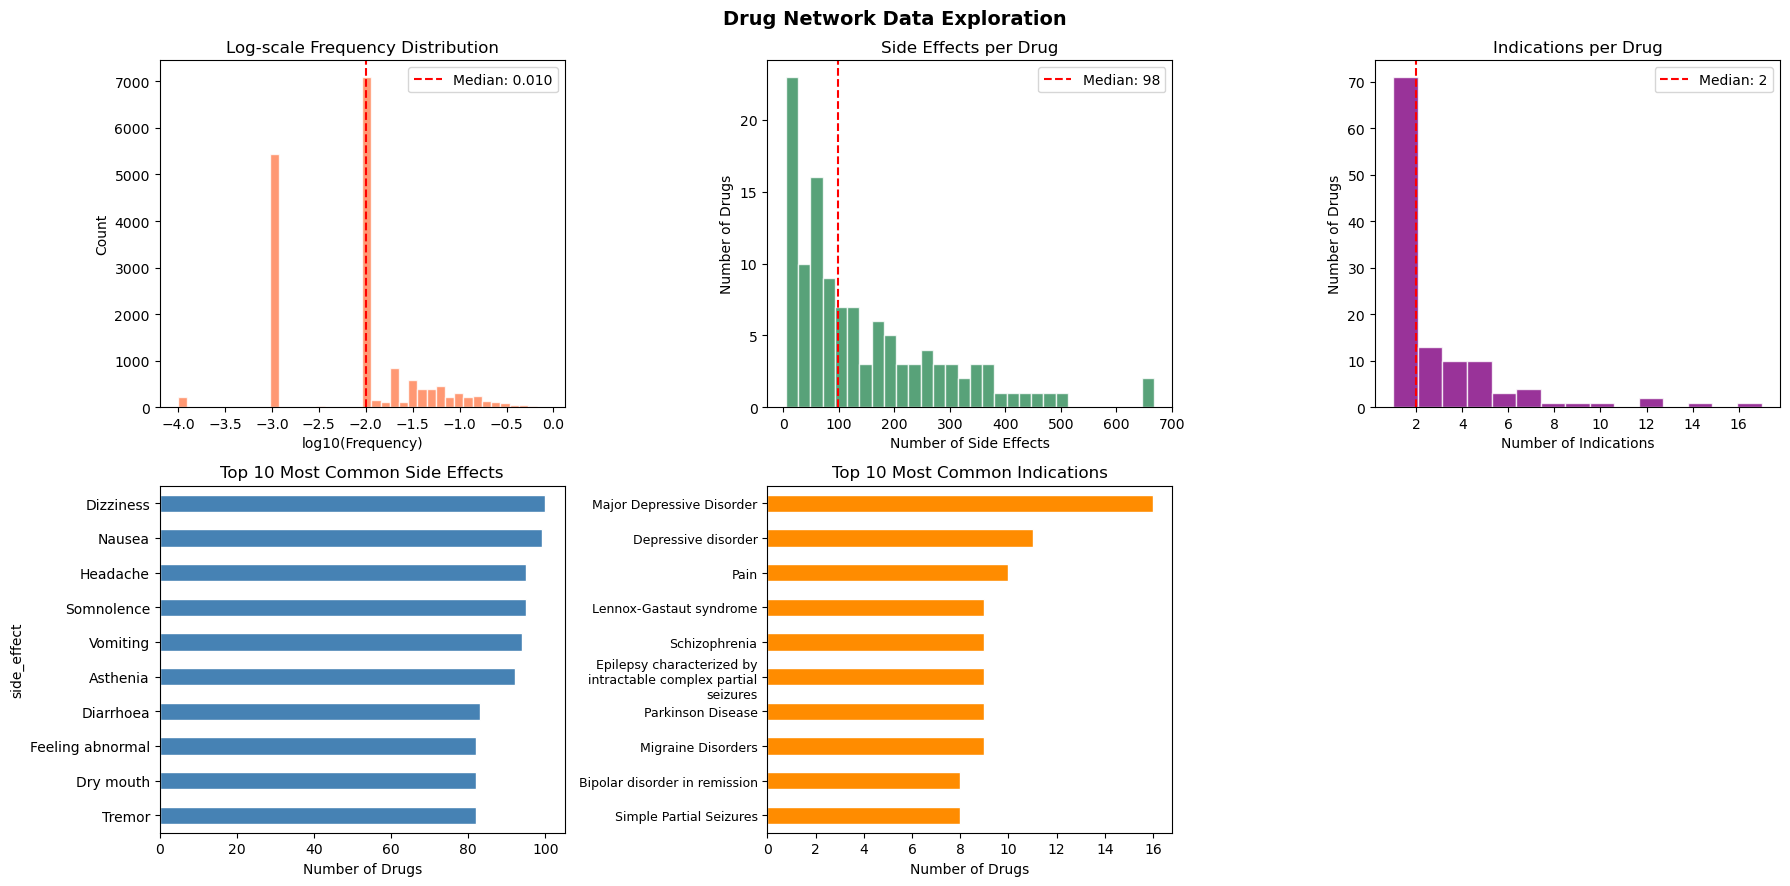

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Drug Network Data Exploration', fontsize=14, fontweight='bold')

# log frequency distribution
ax = axes[0, 0]
log_freq = np.log10(sider_clean['frequency'])
ax.hist(log_freq, bins=40, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(log_freq.median(), color='red', linestyle='--', label=f'Median: {10**log_freq.median():.3f}')
ax.set_xlabel('log10(Frequency)')
ax.set_ylabel('Count')
ax.set_title('Log-scale Frequency Distribution')
ax.legend()

# side effects per drug
ax = axes[0, 1]
se_per_drug = sider_matched.groupby('drug_name_norm')['side_effect'].nunique()
ax.hist(se_per_drug, bins=30, color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(se_per_drug.median(), color='red', linestyle='--', label=f'Median: {se_per_drug.median():.0f}')
ax.set_xlabel('Number of Side Effects')
ax.set_ylabel('Number of Drugs')
ax.set_title('Side Effects per Drug')
ax.legend()

# indications per drug
ax = axes[0, 2]
ind_per_drug = repodb_matched.groupby('drug_name_norm')['ind_name'].nunique()
ax.hist(ind_per_drug, bins=15, color='purple', edgecolor='white', alpha=0.8)
ax.axvline(ind_per_drug.median(), color='red', linestyle='--', label=f'Median: {ind_per_drug.median():.0f}')
ax.set_xlabel('Number of Indications')
ax.set_ylabel('Number of Drugs')
ax.set_title('Indications per Drug')
ax.legend()

# top 10 side effects
ax = axes[1, 0]
top_se = sider_clean.groupby('side_effect')['drug_name_norm'].nunique().sort_values(ascending=True).tail(10)
top_se.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Drugs')
ax.set_title('Top 10 Most Common Side Effects')

# top 10 indications
ax = axes[1, 1]
top_ind = repodb_matched.groupby('ind_name')['drug_name_norm'].nunique().sort_values(ascending=True).tail(10)
wrapped_labels = [textwrap.fill(label, width=30) for label in top_ind.index]
top_ind.index = wrapped_labels
top_ind.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_xlabel('Number of Drugs')
ax.set_title('Top 10 Most Common Indications')
ax.tick_params(axis='y', labelsize=9)

axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.savefig(FIG_DIR / "data_exploration.png", dpi=FIG_DPI, bbox_inches="tight")

## Networks Construction

In [ ]:
# drug - indications network

G_drug_ind = nx.Graph()

drugs = repodb_matched['drug_name_norm'].unique()
for drug in drugs:
    G_drug_ind.add_node(drug, bipartite=0, node_type='drug')

indications = repodb_matched['ind_name'].unique()
for ind in indications:
    G_drug_ind.add_node(ind, bipartite=1, node_type='indication')

for _, row in repodb_matched.iterrows():
    G_drug_ind.add_edge(row['drug_name_norm'], row['ind_name'])

In [ ]:
# drug - SE weighted

G_drug_se_weighted = nx.Graph()

drugs_se = sider_clean['drug_name_norm'].unique()
for drug in drugs_se:
    G_drug_se_weighted.add_node(drug, bipartite=0, node_type='drug')

side_effects = sider_clean['side_effect'].unique()
for se in side_effects:
    G_drug_se_weighted.add_node(se, bipartite=1, node_type='side_effect')

for _, row in sider_clean.iterrows():
    G_drug_se_weighted.add_edge(
        row['drug_name_norm'],
        row['side_effect'],
        weight=row['frequency']
    )

In [ ]:
# drug - SE unweighted

G_drug_se_unweighted = nx.Graph()

for drug in drugs_se:
    G_drug_se_unweighted.add_node(drug, bipartite=0, node_type='drug')
for se in side_effects:
    G_drug_se_unweighted.add_node(se, bipartite=1, node_type='side_effect')

for _, row in sider_clean.iterrows():
    G_drug_se_unweighted.add_edge(row['drug_name_norm'], row['side_effect'])

In [ ]:
# projection drug - drug by shared indications weighted

drug_nodes_ind = {n for n, d in G_drug_ind.nodes(data=True) if d['bipartite'] == 0}

# edge weight = number of shared indications
G_drug_drug_ind = bipartite.weighted_projected_graph(G_drug_ind, drug_nodes_ind)

In [ ]:
# projection drug - drug by shared SE

drug_nodes_se = {n for n, d in G_drug_se_unweighted.nodes(data=True) if d['bipartite'] == 0}

# edge weight = number of shared side effects
G_drug_drug_se = bipartite.weighted_projected_graph(G_drug_se_unweighted, drug_nodes_se)

In [ ]:
# projection drug - drug by SE weighted similarity options

drug_nodes = [n for n, d in G_drug_se_weighted.nodes(data=True) if d['node_type'] == 'drug']
all_se = sorted(sider_clean['side_effect'].unique())
se_to_idx = {se: i for i, se in enumerate(all_se)}
n_se = len(all_se)
drug_vectors = {}
for drug in drug_nodes:
    vec = np.zeros(n_se)
    for neighbor in G_drug_se_weighted.neighbors(drug):
        if neighbor in se_to_idx:
            vec[se_to_idx[neighbor]] = G_drug_se_weighted[drug][neighbor]['weight']
    drug_vectors[drug] = vec

def project_cosine_similarity(drug_vectors):
    G_proj = nx.Graph()
    G_proj.add_nodes_from(drug_vectors.keys())
    drugs = list(drug_vectors.keys())
    for drug1, drug2 in combinations(drugs, 2):
        vec1 = drug_vectors[drug1]
        vec2 = drug_vectors[drug2]
        if np.any(vec1) and np.any(vec2):
            similarity = 1 - cosine(vec1, vec2)
            if similarity > 0:
                n_shared = int(np.sum((vec1 > 0) & (vec2 > 0)))
                G_proj.add_edge(drug1, drug2, weight=similarity, n_shared=n_shared)

    return G_proj

def project_weighted_jaccard(drug_vectors):
    G_proj = nx.Graph()
    G_proj.add_nodes_from(drug_vectors.keys())
    drugs = list(drug_vectors.keys())
    for drug1, drug2 in combinations(drugs, 2):
        vec1 = drug_vectors[drug1]
        vec2 = drug_vectors[drug2]
        min_sum = np.sum(np.minimum(vec1, vec2))
        max_sum = np.sum(np.maximum(vec1, vec2))
        if max_sum > 0:
            similarity = min_sum / max_sum
            if similarity > 0:
                n_shared = int(np.sum((vec1 > 0) & (vec2 > 0)))
                G_proj.add_edge(drug1, drug2, weight=similarity, n_shared=n_shared)

    return G_proj

In [ ]:
G_drug_drug_se_cosine = project_cosine_similarity(drug_vectors)
G_drug_drug_se_jaccard = project_weighted_jaccard(drug_vectors)

In [ ]:
all_networks = {
    'Drug-Indication': G_drug_ind,
    'Drug-SE weighted': G_drug_se_weighted,
    'Drug-SE unweighted': G_drug_se_unweighted,
    'Drug-Drug by indication': G_drug_drug_ind,
    'Drug-Drug by SE count': G_drug_drug_se,
    'Drug-Drug by SE cosine': G_drug_drug_se_cosine,
    'Drug-Drug by SE jaccard': G_drug_drug_se_jaccard}

for name, G in all_networks.items():
    density = nx.density(G)
    print(f"{name}:")
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Density: {density:.4f}")

Drug-Indication:
Nodes: 250, Edges: 352, Density: 0.0113
Drug-SE weighted:
Nodes: 1901, Edges: 17304, Density: 0.0096
Drug-SE unweighted:
Nodes: 1901, Edges: 17304, Density: 0.0096
Drug-Drug by indication:
Nodes: 118, Edges: 552, Density: 0.0800
Drug-Drug by SE count:
Nodes: 118, Edges: 6731, Density: 0.9751
Drug-Drug by SE cosine:
Nodes: 118, Edges: 6731, Density: 0.9751
Drug-Drug by SE jaccard:
Nodes: 118, Edges: 6731, Density: 0.9751


In [ ]:
# save networks
NET_DIR = OUT_DIR / "networks"
NET_DIR.mkdir(parents=True, exist_ok=True)

nx.write_graphml(G_drug_ind, NET_DIR / "network_drug_indication.graphml")
nx.write_graphml(G_drug_se_weighted, NET_DIR / 'network_drug_se_weighted.graphml')
nx.write_graphml(G_drug_se_unweighted, NET_DIR / 'network_drug_se_unweighted.graphml')
nx.write_graphml(G_drug_drug_ind, NET_DIR / 'network_drug_drug_indication.graphml')
nx.write_graphml(G_drug_drug_se, NET_DIR / 'network_drug_drug_se.graphml')
nx.write_graphml(G_drug_drug_se_cosine, NET_DIR / 'network_drug_drug_se_cosine.graphml')
nx.write_graphml(G_drug_drug_se_jaccard, NET_DIR / 'network_drug_drug_se_jaccard.graphml')

## Networks Statistics

In [ ]:
for name, G in all_networks.items():
    print(f"\n{name}:")
    # connected components
    n_components = nx.number_connected_components(G)
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"Connected components: {n_components}")
    print(f"Largest component size: {len(largest_cc)} ({100*len(largest_cc)/G.number_of_nodes():.1f}%)")

    is_bipartite = nx.is_bipartite(G)
    # clustering coef
    if is_bipartite:
        avg_clustering = nx.bipartite.average_clustering(G)
        print(f"Avg Bipartite clustering coefficient: {avg_clustering:.2f}")
    else:
        avg_clustering = nx.average_clustering(G)
        print(f"Avg clustering coefficient: {avg_clustering:.2f}")

    # av degree
    degrees = [d for n, d in G.degree()]
    print(f"Avg degree: {np.mean(degrees):.2f}")
    print(f"Median degree: {np.median(degrees)}")
    print(f"Max degree: {np.max(degrees)}")


Drug-Indication:
Connected components: 8
Largest component size: 232 (92.8%)
Avg Bipartite clustering coefficient: 0.36
Avg degree: 2.82
Median degree: 2.0
Max degree: 17

Drug-SE weighted:
Connected components: 1
Largest component size: 1901 (100.0%)
Avg Bipartite clustering coefficient: 0.14
Avg degree: 18.21
Median degree: 3.0
Max degree: 668

Drug-SE unweighted:
Connected components: 1
Largest component size: 1901 (100.0%)
Avg Bipartite clustering coefficient: 0.14
Avg degree: 18.21
Median degree: 3.0
Max degree: 668

Drug-Drug by indication:
Connected components: 8
Largest component size: 108 (91.5%)
Avg clustering coefficient: 0.71
Avg degree: 9.36
Median degree: 9.0
Max degree: 29

Drug-Drug by SE count:
Connected components: 1
Largest component size: 118 (100.0%)
Avg clustering coefficient: 0.98
Avg degree: 114.08
Median degree: 117.0
Max degree: 117

Drug-Drug by SE cosine:
Connected components: 1
Largest component size: 118 (100.0%)
Avg clustering coefficient: 0.98
Avg degre

In [ ]:
networks1 = {
    'Drug-Indication': G_drug_ind,
    'Drug-SE weighted': G_drug_se_weighted,
    'Drug-SE unweighted': G_drug_se_unweighted,
    'Drug-Drug by indication': G_drug_drug_ind,
    'Drug-Drug by SE count': G_drug_drug_se}

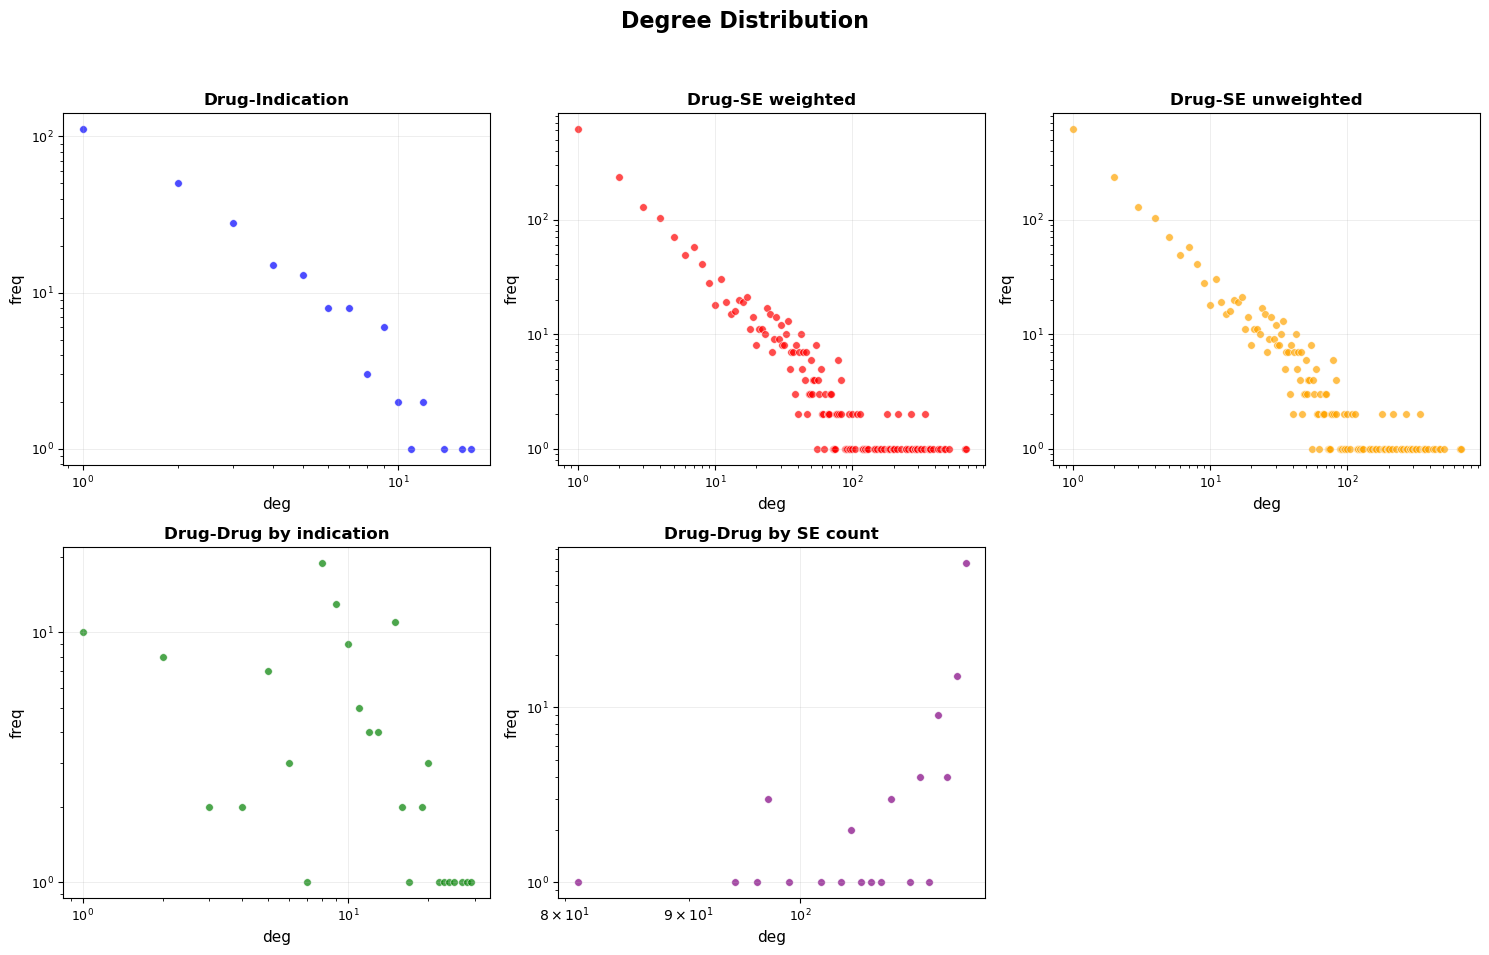

In [ ]:
# degree distribution plots

colors = ['blue', 'red', 'orange', 'green', 'purple']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
fig.suptitle('Degree Distribution', fontsize=16, fontweight='bold')

for idx, (name, G) in enumerate(networks1.items()):
    ax = axes[idx]
    degrees = [d for n, d in G.degree()]
    unique_degrees = sorted(set(degrees))
    freq = [Counter(degrees)[d] for d in unique_degrees]

    ax.scatter(unique_degrees, freq, c=colors[idx], s=30, alpha=0.7, edgecolors='white', linewidth=0.5)

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('deg', fontsize=11)
    ax.set_ylabel('freq', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.tick_params(axis='both', which='major', labelsize=9)

axes[5].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(FIG_DIR / "degree_distribution.png", dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# degree assortativity

for name, G in all_networks.items():
    print(f"{name}:")
    degree_assort = nx.degree_assortativity_coefficient(G)
    print(f"Degree assortativity: {degree_assort:.4f}")
    if degree_assort > 0:
        print(f"Assortative")
    else:
        print(f"Disassortative")

Drug-Indication:
Degree assortativity: -0.2798
Disassortative
Drug-SE weighted:
Degree assortativity: -0.5628
Disassortative
Drug-SE unweighted:
Degree assortativity: -0.5628
Disassortative
Drug-Drug by indication:
Degree assortativity: 0.2370
Assortative
Drug-Drug by SE count:
Degree assortativity: -0.0981
Disassortative
Drug-Drug by SE cosine:
Degree assortativity: -0.0981
Disassortative
Drug-Drug by SE jaccard:
Degree assortativity: -0.0981
Disassortative


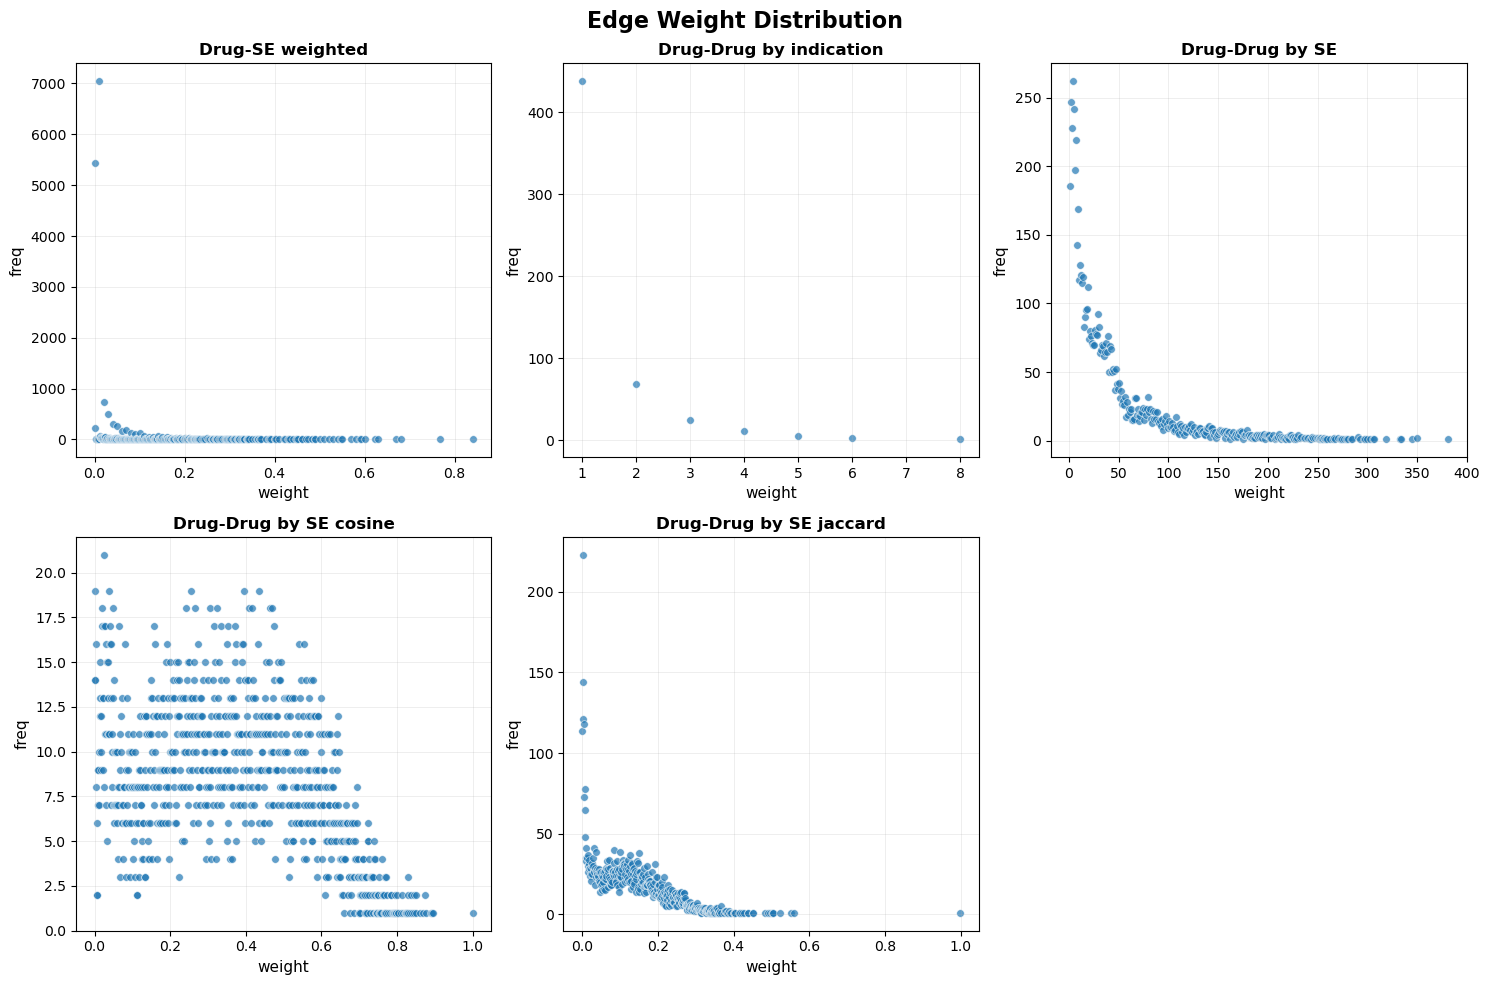

In [ ]:
# edge weights distributions

weighted_networks = {
    'Drug-SE weighted': G_drug_se_weighted,
    'Drug-Drug by indication': G_drug_drug_ind,
    'Drug-Drug by SE': G_drug_drug_se,
    'Drug-Drug by SE cosine': G_drug_drug_se_cosine,
    'Drug-Drug by SE jaccard': G_drug_drug_se_jaccard}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Edge Weight Distribution', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()
for idx, (name, G) in enumerate(weighted_networks.items()):
    ax = axes_flat[idx]
    weights = [d['weight'] for u, v, d in G.edges(data=True)]

    if any(x in name for x in ['SE', 'cosine', 'jaccard']):
        weights_rounded = [round(w, 3) for w in weights]
    else:
        weights_rounded = [int(w) for w in weights]

    unique_weights = sorted(set(weights_rounded))
    freq = [Counter(weights_rounded)[w] for w in unique_weights]

    ax.scatter(unique_weights, freq, s=30, alpha=0.7, edgecolors='white', linewidth=0.5)

    ax.set_xlabel('weight', fontsize=11)
    ax.set_ylabel('freq', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

axes_flat[5].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / "edge_weight_distribution.png", dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show()

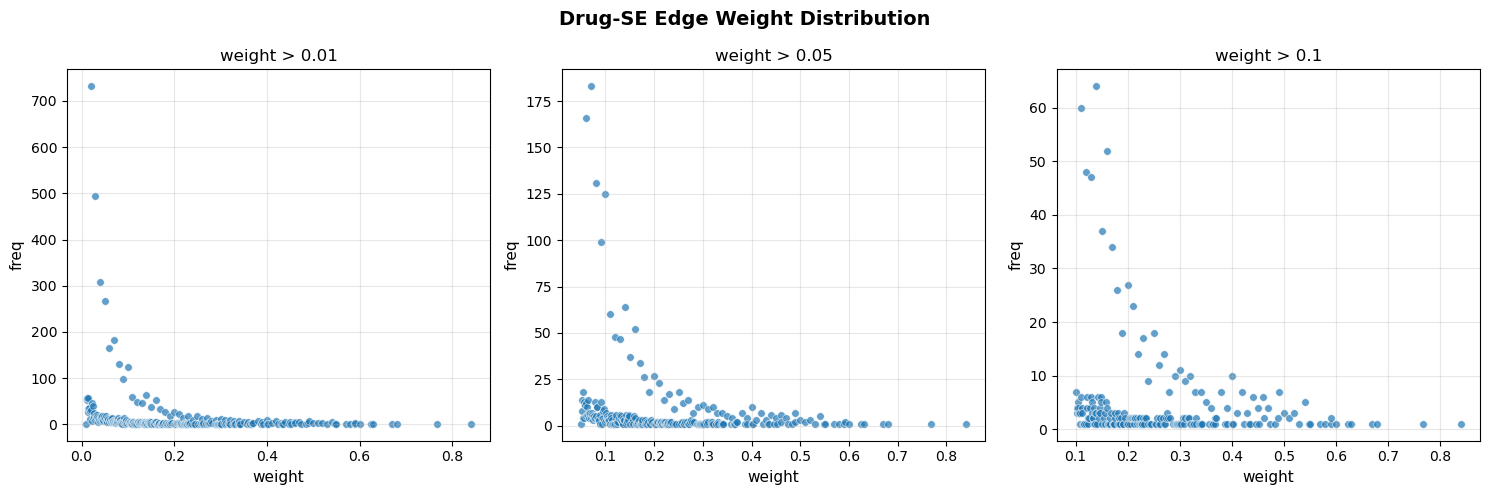

In [ ]:
# edge weights drug - SE filtered

weights = [d['weight'] for u, v, d in G_drug_se_weighted.edges(data=True)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Drug-SE Edge Weight Distribution', fontsize=14, fontweight='bold')

# exclude minimum frequency values
ax = axes[0]
weights_filtered = [w for w in weights if w > 0.01]
weights_rounded = [round(w, 3) for w in weights_filtered]
unique_weights = sorted(set(weights_rounded))
freq = [Counter(weights_rounded)[w] for w in unique_weights]

ax.scatter(unique_weights, freq, s=30, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('weight', fontsize=11)
ax.set_ylabel('freq', fontsize=11)
ax.set_title('weight > 0.01', fontsize=12)
ax.grid(True, alpha=0.3)

# frequencies > 0.05
ax = axes[1]
weights_filtered = [w for w in weights if w > 0.05]
weights_rounded = [round(w, 3) for w in weights_filtered]
unique_weights = sorted(set(weights_rounded))
freq = [Counter(weights_rounded)[w] for w in unique_weights]

ax.scatter(unique_weights, freq, s=30, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('weight', fontsize=11)
ax.set_ylabel('freq', fontsize=11)
ax.set_title('weight > 0.05', fontsize=12)
ax.grid(True, alpha=0.3)

# frequencies > 0.1
ax = axes[2]
weights_filtered = [w for w in weights if w > 0.1]
weights_rounded = [round(w, 3) for w in weights_filtered]
unique_weights = sorted(set(weights_rounded))
freq = [Counter(weights_rounded)[w] for w in unique_weights]

ax.scatter(unique_weights, freq, s=30, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('weight', fontsize=11)
ax.set_ylabel('freq', fontsize=11)
ax.set_title('weight > 0.1', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "drug_se_weight_distribution_filtered.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## Centrality analysis

In [ ]:
# Drug - Indication network

drug_nodes = [n for n, d in G_drug_ind.nodes(data=True) if d.get('node_type') == 'drug']
ind_nodes = [n for n, d in G_drug_ind.nodes(data=True) if d.get('node_type') == 'indication']
drug_set = set(drug_nodes)

degree_cent = bipartite.degree_centrality(G_drug_ind, drug_set)
drug_degree = {n:degree_cent[n] for n in drug_nodes}
ind_degree = {n:degree_cent[n] for n in ind_nodes}
print("Top degree drugs:")
for drug, cent in sorted(drug_degree.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top degree indications:")
for ind, cent in sorted(ind_degree.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{ind}: {cent:.4f}")

betweenness = bipartite.betweenness_centrality(G_drug_ind, drug_set)
drug_between = {n:betweenness[n] for n in drug_nodes}
ind_between = {n:betweenness[n] for n in ind_nodes}
print("Top betweenness drugs:")
for drug, cent in sorted(drug_between.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top betweenness indications:")
for ind, cent in sorted(ind_between.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{ind}: {cent:.4f}")

closeness = bipartite.closeness_centrality(G_drug_ind, drug_set)
drug_close = {n:closeness[n] for n in drug_nodes}
ind_close = {n:closeness[n] for n in ind_nodes}
print("Top closeness drugs:")
for drug, cent in sorted(drug_close.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top closeness indications:")
for ind, cent in sorted(ind_close.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{ind}: {cent:.4f}")

pagerank = nx.pagerank(G_drug_ind)
drug_pr = {n:pagerank[n] for n in drug_nodes}
ind_pr = {n:pagerank[n] for n in ind_nodes}
print("Top PageRank drugs:")
for drug, cent in sorted(drug_pr.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top PageRank indications:")
for ind, cent in sorted(ind_pr.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{ind}: {cent:.4f}")

Top degree drugs:
caffeine: 0.1288
scopolamine: 0.1061
lidocaine: 0.0909
carbamazepine: 0.0909
phenytoin: 0.0758
Top degree indications:
Major Depressive Disorder: 0.1356
Depressive disorder: 0.0932
Pain: 0.0847
Parkinson Disease: 0.0763
Lennox-Gastaut syndrome: 0.0763
Top betweenness drugs:
caffeine: 0.3063
diazepam: 0.1946
doxepin: 0.1760
bupropion: 0.1455
gabapentin: 0.1310
Top betweenness indications:
Postherpetic neuralgia: 0.1737
Muscle Spasticity: 0.1701
Major Depressive Disorder: 0.1697
Severe pain: 0.1322
Restless Legs Syndrome: 0.1248
Top closeness drugs:
riluzole: 1.4699
sufentanil: 1.4699
tetrabenazine: 1.4699
zonisamide: 1.4699
betahistine: 1.4699
Top closeness indications:
Myasthenia Gravis: 1.5261
Amyotrophic Lateral Sclerosis: 1.5261
Pain, Postoperative: 1.5261
Huntington Disease: 1.5261
Lewy Body Disease: 1.5261
Top PageRank drugs:
caffeine: 0.0228
scopolamine: 0.0201
lidocaine: 0.0192
carbamazepine: 0.0110
doxepin: 0.0107
Top PageRank indications:
Major Depressive Dis

In [ ]:
# invert edge weights for distances centralities
def invert_weights(G):
    G_copy = G.copy()
    for u, v, d in G_copy.edges(data=True):
        if 'weight' in d and d['weight'] > 0:
            d['distance'] = 1.0 / d['weight']
        else:
            d['distance'] = 1.0
    return G_copy

In [ ]:
# Drug - SE weighted network

G_inv = invert_weights(G_drug_se_weighted)
drug_nodes = [n for n, d in G_drug_se_weighted.nodes(data=True) if d.get('node_type') == 'drug']
se_nodes = [n for n, d in G_drug_se_weighted.nodes(data=True) if d.get('node_type') == 'side_effect']
drug_set = set(drug_nodes)

degree_cent = bipartite.degree_centrality(G_drug_se_weighted, drug_set)
drug_degree = {n:degree_cent[n] for n in drug_nodes}
se_degree = {n:degree_cent[n] for n in se_nodes}

print("Top degree drugs (most SE):")
for drug, cent in sorted(drug_degree.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top degree SE (most drugs):")
for se, cent in sorted(se_degree.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{se}: {cent:.4f}")
drug_strength = {n:sum(G_drug_se_weighted[n][neighbor]['weight'] for neighbor in G_drug_se_weighted.neighbors(n)) for n in drug_nodes}
se_strength = {n:sum(G_drug_se_weighted[n][neighbor]['weight'] for neighbor in G_drug_se_weighted.neighbors(n)) for n in se_nodes}
print("Top total SE frequency burden:")
for drug, cent in sorted(drug_strength.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top side effects by cumulative frequency:")
for se, cent in sorted(se_strength.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{se}: {cent:.4f}")
closeness = bipartite.closeness_centrality(G_drug_se_weighted, drug_set)
drug_close = {n:closeness[n] for n in drug_nodes}
se_close = {n:closeness[n] for n in se_nodes}
print("Top drug closeness:")
for drug, cent in sorted(drug_close.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top SE closeness:")
for se, cent in sorted(se_close.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{se}: {cent:.4f}")
betweenness = bipartite.betweenness_centrality(G_drug_se_weighted, drug_set)
drug_between = {n:betweenness[n] for n in drug_nodes}
se_between = {n:betweenness[n] for n in se_nodes}
print("Top drug betweenness:")
for drug, cent in sorted(drug_between.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top SE betweenness:")
for se, cent in sorted(se_between.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{se}: {cent:.4f}")
pagerank = nx.pagerank(G_drug_se_weighted, weight='weight')
drug_pr = {n:pagerank[n] for n in drug_nodes}
se_pr = {n:pagerank[n] for n in se_nodes}
print("Top drug PageRank:")
for drug, cent in sorted(drug_pr.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")
print("Top SE PageRank:")
for se, cent in sorted(se_pr.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{se}: {cent:.4f}")

Top degree drugs (most SE):
citalopram: 0.3746
pregabalin: 0.3730
paroxetine: 0.2815
venlafaxine: 0.2630
ropinirole: 0.2619
Top degree SE (most drugs):
Dizziness: 0.8475
Nausea: 0.8390
Headache: 0.8051
Somnolence: 0.8051
Vomiting: 0.7966
Top total SE frequency burden:
risperidone: 19.3960
topiramate: 15.9602
alprazolam: 14.0730
clomipramine: 13.3297
vigabatrin: 10.8840
Top side effects by cumulative frequency:
Somnolence: 18.7232
Nausea: 18.4739
Headache: 15.2926
Dizziness: 14.8756
Asthenia: 10.7358
Top drug closeness:
citalopram: 0.4749
pregabalin: 0.4743
paroxetine: 0.4405
venlafaxine: 0.4342
ropinirole: 0.4339
Top SE closeness:
Nausea: 0.9829
Dizziness: 0.9803
Vomiting: 0.9793
Somnolence: 0.9730
Headache: 0.9720
Top drug betweenness:
citalopram: 0.1728
pregabalin: 0.1465
ropinirole: 0.0784
tramadol: 0.0775
paroxetine: 0.0613
Top SE betweenness:
Nausea: 0.0080
Vomiting: 0.0077
Dizziness: 0.0073
Somnolence: 0.0068
Headache: 0.0067
Top drug PageRank:
risperidone: 0.0187
citalopram: 0.0

In [ ]:
# Drug - Drug by shared Indications weighted

G_inv = invert_weights(G_drug_drug_ind)

degree_cent = nx.degree_centrality(G_drug_drug_ind)
print("Top degree drugs")
for drug, cent in sorted(degree_cent.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

strength = {n:sum(d['weight'] for _, _, d in G_drug_drug_ind.edges(n, data=True)) for n in G_drug_drug_ind.nodes()}
print("Top by strength")
for drug, s in sorted(strength.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {s:.0f}")

closeness = nx.closeness_centrality(G_inv, distance='distance')
print("Top drug by closeness")
for drug, cent in sorted(closeness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

betweenness = nx.betweenness_centrality(G_inv, weight='distance')
print("Top drug by betweenness")
for drug, cent in sorted(betweenness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

pagerank = nx.pagerank(G_drug_drug_ind, weight='weight')
print("Top drug by PageRank")
for drug, cent in sorted(pagerank.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

Top degree drugs
paroxetine: 0.2479
fluoxetine: 0.2393
olanzapine: 0.2308
citalopram: 0.2137
bupropion: 0.2051
Top by strength
carbamazepine: 52
paroxetine: 47
phenytoin: 45
olanzapine: 44
fluoxetine: 40
Top drug by closeness
fluoxetine: 0.4700
paroxetine: 0.4638
olanzapine: 0.4532
sertraline: 0.4429
bupropion: 0.4409
Top drug by betweenness
caffeine: 0.2456
olanzapine: 0.1919
gabapentin: 0.1556
diazepam: 0.1535
carbamazepine: 0.1516
Top drug by PageRank
paroxetine: 0.0233
carbamazepine: 0.0214
caffeine: 0.0212
olanzapine: 0.0199
fluoxetine: 0.0198


In [ ]:
# Drug - Drug by shared Side effects weighted

G_inv = invert_weights(G_drug_drug_se)

degree_cent = nx.degree_centrality(G_drug_drug_se)
print("Top degree drugs")
for drug, cent in sorted(degree_cent.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

strength = {n:sum(d['weight'] for _, _, d in G_drug_drug_ind.edges(n, data=True)) for n in G_drug_drug_se.nodes()}
print("Top by strength")
for drug, s in sorted(strength.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {s:.0f}")

closeness = nx.closeness_centrality(G_inv, distance='distance')
print("Top drug by closeness")
for drug, cent in sorted(closeness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

betweenness = nx.betweenness_centrality(G_inv, weight='distance')
print("Top drug by betweenness")
for drug, cent in sorted(betweenness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

pagerank = nx.pagerank(G_drug_drug_se, weight='weight')
print("Top drug by PageRank")
for drug, cent in sorted(pagerank.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

Top degree drugs
pregabalin: 1.0000
clobazam: 1.0000
zolpidem: 1.0000
bromocriptine: 1.0000
tapentadol: 1.0000
Top by strength
carbamazepine: 52
paroxetine: 47
phenytoin: 45
olanzapine: 44
fluoxetine: 40
Top drug by closeness
citalopram: 31.2227
paroxetine: 30.6639
pregabalin: 30.5321
risperidone: 30.2175
gabapentin: 30.0419
Top drug by betweenness
citalopram: 0.3904
pregabalin: 0.1030
paroxetine: 0.0941
risperidone: 0.0484
gabapentin: 0.0470
Top drug by PageRank
citalopram: 0.0201
pregabalin: 0.0199
paroxetine: 0.0194
venlafaxine: 0.0180
gabapentin: 0.0179


## Community detection, Indications

In [ ]:
networks = {
    'Drug-Drug by indication': G_drug_drug_ind}

In [ ]:
# performance evaluation functions

def partition_to_C(G_ig, membership):
    n_nodes = G_ig.vcount()
    n_communities = len(set(membership))
    unique_comms = sorted(set(membership))
    comm_map = {c: i for i, c in enumerate(unique_comms)}

    row_ind = list(range(n_nodes))
    col_ind = [comm_map[membership[i]] for i in range(n_nodes)]
    data = [1] * n_nodes

    C = sps.csr_matrix((data, (row_ind, col_ind)), shape=(n_nodes, n_communities))
    return C

def get_Pdd(G_ig, weighted=True):
    if 'weight' in G_ig.es.attributes():
        adj = np.array(G_ig.get_adjacency(attribute='weight').data)
    else:
        adj = np.array(G_ig.get_adjacency().data)
    total = adj.sum()
    if total > 0:
        Pdd = sps.csr_matrix(adj / total)
    else:
        Pdd = sps.csr_matrix(adj)
    return Pdd

def logg(x):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    mask = x > 0
    y[mask] = np.log(x[mask])
    return y

def ncut_fn(Pcc):
    row_sums = np.array(Pcc.sum(axis=0)).flatten()
    diagonal = np.array(Pcc.diagonal()).flatten()
    valid = row_sums > 0
    if valid.sum() == 0:
        return 0.0
    ncut_per_community = np.zeros_like(row_sums)
    ncut_per_community[valid] = (row_sums[valid] - diagonal[valid]) / row_sums[valid]
    ncut = ncut_per_community[valid].mean()
    return ncut

def compute_ncut(G_ig, membership, weighted=True):
    Pdd = get_Pdd(G_ig, weighted=weighted)
    C = partition_to_C(G_ig, membership)
    Pcc = (C.T).dot(Pdd).dot(C)
    ncut = ncut_fn(Pcc)
    return ncut

def nmi_fn(Pnc):
    pn = np.array(Pnc.sum(axis=1)).flatten()
    pc = np.array(Pnc.sum(axis=0)).flatten()
    Hc = -np.sum(pc * logg(pc))
    if Hc == 0:
        return 0.0
    Pnc_dense = Pnc.toarray() if sps.issparse(Pnc) else Pnc
    mutual_info = 0.0
    for i in range(Pnc_dense.shape[0]):
        for j in range(Pnc_dense.shape[1]):
            if Pnc_dense[i, j] > 0 and pn[i] > 0 and pc[j] > 0:
                mutual_info += Pnc_dense[i, j] * np.log(Pnc_dense[i, j] / (pn[i] * pc[j]))
    nmi = mutual_info / Hc
    return nmi

def compute_nmi_internal(G_ig, membership, weighted=True):
    n_nodes = G_ig.vcount()
    n_communities = len(set(membership))
    if 'weight' in G_ig.es.attributes():
        strengths = np.array(G_ig.strength(weights='weight'))
    else:
        strengths = np.array(G_ig.degree())
    total_strength = strengths.sum()
    if total_strength == 0:
        return 0.0
    pn = strengths / total_strength
    C = partition_to_C(G_ig, membership)
    Pnc = sps.diags(pn).dot(C)
    nmi = nmi_fn(Pnc)
    return nmi

In [ ]:
# Louvain

def run_louvain(G, weighted=True, resolution=1.0, partition_type='modularity'):
    G_ig = ig.Graph.from_networkx(G)
    weights = G_ig.es['weight']

    if partition_type == 'modularity':
        part = la.find_partition(
            G_ig,
            la.ModularityVertexPartition,
            weights=weights)

    elif partition_type == 'rb':
        part = la.find_partition(
            G_ig,
            la.RBConfigurationVertexPartition,
            weights=weights,
            resolution_parameter=resolution)

    elif partition_type == 'cpm':
        part = la.find_partition(
            G_ig,
            la.CPMVertexPartition,
            weights=weights,
            resolution_parameter=resolution)

    membership = part.membership
    quality = part.quality()
    n_communities = len(set(membership))
    modularity = G_ig.modularity(membership, weights=weights)
    partition = {G_ig.vs[i]['_nx_name']: membership[i] for i in range(len(G_ig.vs))}

    return partition, membership, quality, n_communities, modularity, G_ig

In [ ]:
# infomap

def run_infomap(G, weighted=True):
    G_ig = ig.Graph.from_networkx(G)
    weights = G_ig.es['weight']

    result = G_ig.community_infomap(edge_weights=weights)
    membership = result.membership
    n_communities = len(set(membership))
    modularity = G_ig.modularity(membership, weights=weights)
    codelength = result.codelength
    partition = {G_ig.vs[i]['_nx_name']: membership[i] for i in range(len(G_ig.vs))}

    return partition, membership, n_communities, modularity, G_ig, codelength

In [ ]:
# edge betweenness

def run_edge_betweenness(G, weighted=True, n_clusters=None):
    G_inv = invert_weights(G)
    G_ig = ig.Graph.from_networkx(G_inv)
    distances = G_ig.es['distance']
    dendrogram = G_ig.community_edge_betweenness(weights=distances, directed=False)

    if n_clusters is not None:
        result = dendrogram.as_clustering(n=n_clusters)
    else:
        result = dendrogram.as_clustering()

    membership = result.membership
    n_communities = len(set(membership))
    weights = G_ig.es['weight']
    modularity = G_ig.modularity(membership, weights=weights)
    partition = {G_ig.vs[i]['_nx_name']: membership[i] for i in range(len(G_ig.vs))}

    return partition, membership, n_communities, modularity, G_ig, dendrogram

In [ ]:
# optimal (since graphs are small)

def run_optimal_mod(G, weighted=True):
    G_ig = ig.Graph.from_networkx(G)
    weights = G_ig.es['weight']

    result = G_ig.community_optimal_modularity(weights=weights)
    membership = result.membership
    n_communities = len(set(membership))
    modularity = G_ig.modularity(membership, weights=weights)
    partition = {G_ig.vs[i]['_nx_name']: membership[i] for i in range(len(G_ig.vs))}

    return partition, membership, n_communities, modularity, G_ig

In [ ]:
# run algorithms

results = {}

for name, G in networks.items():
    print(f"{name}")
    results[name] = {}

    # Louvain with ModularityVertexPartition
    print("\nLouvain with ModularityVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, partition_type='modularity')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_mod'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Louvain with RBConfiguration
    print("\nLouvain RBConfigurationVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, resolution=1.0, partition_type='rb')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_rb'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Louvain CPM
    print("\nLouvain CPMVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, resolution=0.1, partition_type='cpm')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_cpm'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Infomap
    print("\nInfomap")
    partition, membership, n_comm, modularity, G_ig, codelength = run_infomap(
        G, weighted=True)

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Codelength: {codelength:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['infomap'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'codelength': codelength,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Edge betweenness
    print("\nEdge betweenness")
    partition, membership, n_comm, modularity, G_ig, dendrogram = run_edge_betweenness(
        G, weighted=True)

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['edge_betweenness'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Optimal modularity
    print("\nOptimal modularity")
    partition, membership, n_comm, modularity, G_ig = run_optimal_mod(
        G, weighted=True)

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['optimal'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

Drug-Drug by indication

Louvain with ModularityVertexPartition
Communities: 14
Quality: 0.6743
Modularity: 0.6743
NCut: 0.0979
NMI: 1.0000
Sizes: [29, 22, 16, 15, 11, 8, 7, 3, 2, 1, 1, 1, 1, 1]

Louvain RBConfigurationVertexPartition
Communities: 14
Quality: 1006.1180
Modularity: 0.6743
NCut: 0.0979
NMI: 1.0000
Sizes: [29, 22, 16, 15, 11, 8, 7, 3, 2, 1, 1, 1, 1, 1]

Louvain CPMVertexPartition
Communities: 22
Quality: 1169.8000
Modularity: 0.6393
NCut: 0.4947
NMI: 1.0000
Sizes: [27, 25, 17, 11, 8, 7, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Infomap
Communities: 16
Codelength: 4.6808
Modularity: 0.6716
NCut: 0.1515
NMI: 1.0000
Sizes: [29, 19, 16, 12, 11, 8, 7, 3, 3, 3, 2, 1, 1, 1, 1, 1]

Edge betweenness
Communities: 12
Modularity: 0.6215
NCut: 0.0608
NMI: 1.0000
Sizes: [34, 30, 25, 12, 7, 3, 2, 1, 1, 1, 1, 1]

Optimal modularity
Communities: 14
Modularity: 0.6748
NCut: 0.1128
NMI: 1.0000
Sizes: [28, 22, 16, 12, 11, 11, 8, 3, 2, 1, 1, 1, 1, 1]


In [ ]:
algorithms = ['louvain_mod', 'louvain_rb', 'louvain_cpm', 'infomap', 'edge_betweenness', 'optimal']
alg_names = ['Louvain (Mod)', 'Louvain (RB)', 'Louvain (CPM)', 'Infomap', 'Edge Betweenness', 'Optimal Mod']

for name in results.keys():
    print(name)
    for alg, alg_name in zip(algorithms, alg_names):
        r = results[name][alg]
        n_comm = r.get('n_communities')
        modularity = r.get('modularity')
        ncut = r.get('ncut')
        nmi = r.get('nmi')
        print(f"{alg_name}: {n_comm} communities, modularity={modularity:.4f}, Ncut={ncut:.4f}, NMI={nmi:.4f}")

Drug-Drug by indication
Louvain (Mod): 14 communities, modularity=0.6743, Ncut=0.0979, NMI=1.0000
Louvain (RB): 14 communities, modularity=0.6743, Ncut=0.0979, NMI=1.0000
Louvain (CPM): 22 communities, modularity=0.6393, Ncut=0.4947, NMI=1.0000
Infomap: 16 communities, modularity=0.6716, Ncut=0.1515, NMI=1.0000
Edge Betweenness: 12 communities, modularity=0.6215, Ncut=0.0608, NMI=1.0000
Optimal Mod: 14 communities, modularity=0.6748, Ncut=0.1128, NMI=1.0000


## Save for visualization

In [ ]:
G = G_drug_drug_ind.copy()
G_inv = invert_weights(G_drug_drug_ind)
degree_cent = nx.degree_centrality(G)
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
closeness = nx.closeness_centrality(G_inv, distance='distance')
betweenness = nx.betweenness_centrality(G_inv, weight='distance')
pagerank = nx.pagerank(G, weight='weight')

In [ ]:
network_name = 'Drug-Drug by indication'
algorithms = ['louvain_mod', 'louvain_rb', 'infomap', 'edge_betweenness', 'optimal']
alg_attr_names = {
    'louvain_mod': 'comm_louvain_mod',
    'louvain_rb': 'comm_louvain_rb',
    'infomap': 'comm_infomap',
    'edge_betweenness': 'comm_edge_betw',
    'optimal': 'comm_optimal'}

In [ ]:
for alg in algorithms:
    partition = results[network_name][alg]['partition']
    attr_name = alg_attr_names[alg]
    nx.set_node_attributes(G, partition, attr_name)

In [ ]:
for node in G.nodes():
    if node in atc_map:
        G.nodes[node]['atc_full'] = atc_map[node]['atc_full']
        G.nodes[node]['atc2'] = atc_map[node]['atc2']
        G.nodes[node]['atc3'] = atc_map[node]['atc3']
        G.nodes[node]['atc4'] = atc_map[node]['atc4']

In [ ]:
nx.set_node_attributes(G, degree_cent, 'degree_centrality')
nx.set_node_attributes(G, strength, 'strength')
nx.set_node_attributes(G, closeness, 'closeness_centrality')
nx.set_node_attributes(G, betweenness, 'betweenness_centrality')
nx.set_node_attributes(G, pagerank, 'pagerank')

In [ ]:
with open(OUT_DIR / 'drug_drug_indication_communities.pkl', 'wb') as f:
    pickle.dump(G, f)

results_to_save = {alg: results[network_name][alg] for alg in algorithms}
with open(OUT_DIR / 'community_detection_results.pkl', 'wb') as f:
    pickle.dump(results_to_save, f)

In [ ]:
nx.write_graphml(G, NET_DIR / "drug_drug_indication_communities.graphml")

## Community detection, Side effects

In [ ]:
# sparsify graph by thresholding edges

def threshold_graph(G, threshold):
    G_thresh = nx.Graph()
    G_thresh.add_nodes_from(G.nodes(data=True))
    for u, v, d in G.edges(data=True):
        if d['weight'] >= threshold:
            G_thresh.add_edge(u, v, **d)
    return G_thresh

In [ ]:
for G, name in [(G_drug_drug_se_cosine, 'Cosine'), (G_drug_drug_se_jaccard, 'Jaccard')]:
    print(name)
    for thresh in [0.03, 0.05, 0.07, 0.1, 0.2, 0.3]:
        G_t = threshold_graph(G, thresh)
        n_edges = G_t.number_of_edges()
        density = nx.density(G_t) if G_t.number_of_nodes() > 1 else 0
        n_components = nx.number_connected_components(G_t)
        isolated = sum(1 for n in G_t.nodes() if G_t.degree(n) == 0)
        print(f"threshold={thresh}: {n_edges} edges, density={density:.4f}, components={n_components}, isolated={isolated}")

Cosine
threshold=0.03: 6375 edges, density=0.9235, components=1, isolated=0
threshold=0.05: 6124 edges, density=0.8872, components=1, isolated=0
threshold=0.07: 5952 edges, density=0.8622, components=1, isolated=0
threshold=0.1: 5710 edges, density=0.8272, components=1, isolated=0
threshold=0.2: 4850 edges, density=0.7026, components=4, isolated=3
threshold=0.3: 3782 edges, density=0.5479, components=8, isolated=7
Jaccard
threshold=0.03: 5089 edges, density=0.7372, components=1, isolated=0
threshold=0.05: 4574 edges, density=0.6626, components=2, isolated=1
threshold=0.07: 4107 edges, density=0.5950, components=6, isolated=4
threshold=0.1: 3363 edges, density=0.4872, components=12, isolated=9
threshold=0.2: 1119 edges, density=0.1621, components=24, isolated=23
threshold=0.3: 177 edges, density=0.0256, components=56, isolated=52


In [ ]:
G_drug_drug_se_jaccard_filter = threshold_graph(G_drug_drug_se_jaccard, threshold=JACCARD_THRESHOLD)

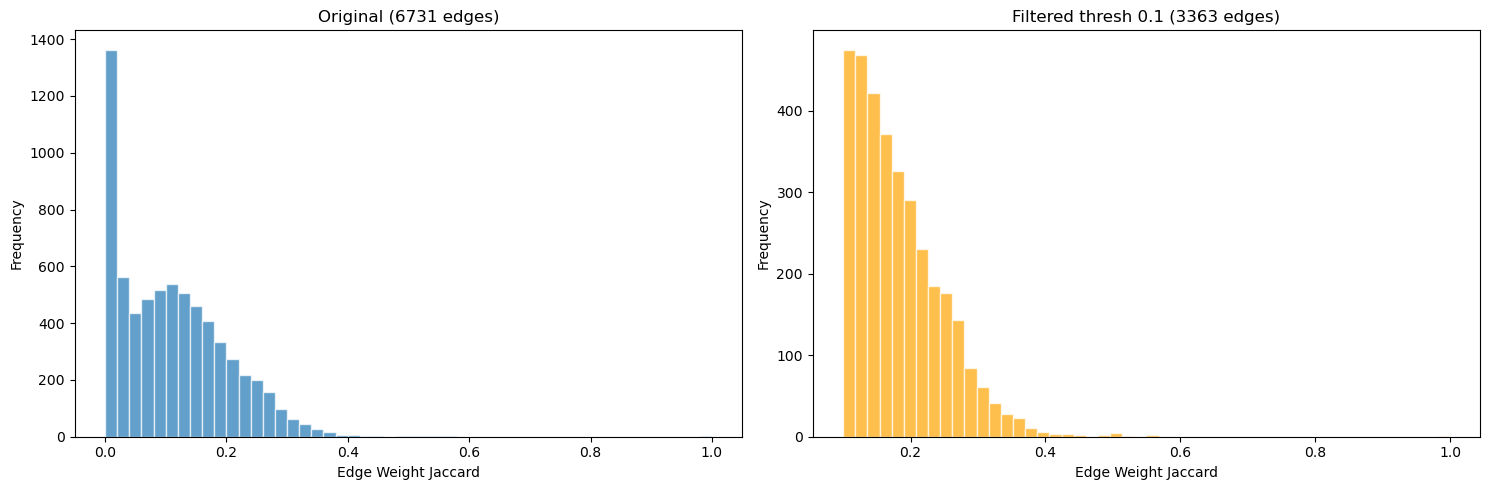

In [ ]:
# visualizations

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
weights_orig = [d['weight'] for _, _, d in G_drug_drug_se_jaccard.edges(data=True)]
ax.hist(weights_orig, bins=50, edgecolor='white', alpha=0.7, label='Original')
ax.set_xlabel('Edge Weight Jaccard')
ax.set_ylabel('Frequency')
ax.set_title(f'Original ({G_drug_drug_se_jaccard.number_of_edges()} edges)')

ax = axes[1]
weights_filt = [d['weight'] for _, _, d in G_drug_drug_se_jaccard_filter.edges(data=True)]
ax.hist(weights_filt, bins=50, edgecolor='white', alpha=0.7, color='orange', label='Filtered')
ax.set_xlabel('Edge Weight Jaccard')
ax.set_ylabel('Frequency')
ax.set_title(f'Filtered thresh 0.1 ({G_drug_drug_se_jaccard_filter.number_of_edges()} edges)')

plt.tight_layout()
plt.savefig(FIG_DIR / "jaccard_filter_analysis.png", dpi=FIG_DPI, bbox_inches="tight")

In [ ]:
# disparity filter

def disparity_integral(x, k):
    assert x != 1.0, "x == 1.0"
    assert k != 1.0, "k == 1.0"
    return ((1.0 - x)**k) / ((k - 1.0) * (x - 1.0))


def get_disparity_significance(norm_weight, degree):
    return 1.0 - ((degree - 1.0) * (disparity_integral(norm_weight, degree) - disparity_integral(0.0, degree)))


def disparity_filter(graph, weight='weight'):
    G = graph.copy()
    alpha_measures = []

    for node_id in G.nodes():
        strength = sum(G[node_id][nbr][weight] for nbr in G.neighbors(node_id))
        G.nodes[node_id]['strength'] = strength

    for u, v, data in G.edges(data=True):
        edge_weight = data[weight]

        strength_u = G.nodes[u]['strength']
        degree_u = G.degree(u)
        norm_weight_u = edge_weight / strength_u if strength_u > 0 else 0

        strength_v = G.nodes[v]['strength']
        degree_v = G.degree(v)
        norm_weight_v = edge_weight / strength_v if strength_v > 0 else 0

        alpha_u = 1.0
        alpha_v = 1.0

        if degree_u > 1:
            nw = min(norm_weight_u, 0.9999)
            try:
                alpha_u = get_disparity_significance(nw, degree_u)
            except:
                alpha_u = 1.0

        if degree_v > 1:
            nw = min(norm_weight_v, 0.9999)
            try:
                alpha_v = get_disparity_significance(nw, degree_v)
            except:
                alpha_v = 1.0

        alpha = min(alpha_u, alpha_v)
        G[u][v]['alpha'] = alpha
        G[u][v]['alpha_u'] = alpha_u
        G[u][v]['alpha_v'] = alpha_v
        G[u][v]['norm_weight_u'] = norm_weight_u
        G[u][v]['norm_weight_v'] = norm_weight_v
        alpha_measures.append(alpha)

    for u, v in G.edges():
        G[u][v]['alpha_ptile'] = percentileofscore(alpha_measures, G[u][v]['alpha']) / 100.0

    return G, alpha_measures


def cut_graph_by_alpha(graph, alpha_cutoff=0.05):
    G_cut = nx.Graph()
    G_cut.add_nodes_from(graph.nodes(data=True))
    for u, v, data in graph.edges(data=True):
        if data['alpha'] < alpha_cutoff:
            G_cut.add_edge(u, v, **data)
    return G_cut


def cut_graph_by_percentile(graph, min_alpha_ptile=0.5):
    G_cut = nx.Graph()
    G_cut.add_nodes_from(graph.nodes(data=True))
    for u, v, data in graph.edges(data=True):
        if data['alpha_ptile'] < min_alpha_ptile:
            G_cut.add_edge(u, v, **data)
    return G_cut

In [ ]:
G_with_alpha, alpha_measures = disparity_filter(G_drug_drug_se_cosine, weight='weight')

print(f"Alpha values: {len(alpha_measures)}")
print(f"Alpha range: [{min(alpha_measures):.6f}, {max(alpha_measures):.6f}]")
print(f"Alpha median: {np.median(alpha_measures):.6f}")

for alpha_cutoff in [0.5, 0.4, 0.3, 0.2, 0.15, 0.05]:
    G_cut = cut_graph_by_alpha(G_with_alpha, alpha_cutoff=alpha_cutoff)
    n_edges = G_cut.number_of_edges()
    density = nx.density(G_cut) if n_edges > 0 else 0
    n_comp = nx.number_connected_components(G_cut)
    isolated = sum(1 for n in G_cut.nodes() if G_cut.degree(n) == 0)
    pct_kept = 100 * n_edges / G_drug_drug_se_cosine.number_of_edges()
    print(f"cutoff={alpha_cutoff}, {n_edges} edges, density={density:.4f}, components={n_comp}, isolated={isolated}, % kept={pct_kept:.1f}")

Alpha values: 6731
Alpha range: [0.000758, 0.999238]
Alpha median: 0.293855
cutoff=0.5, 5765 edges, density=0.8351, components=1, isolated=0, % kept=85.6
cutoff=0.4, 5039 edges, density=0.7300, components=1, isolated=0, % kept=74.9
cutoff=0.3, 3505 edges, density=0.5078, components=1, isolated=0, % kept=52.1
cutoff=0.2, 875 edges, density=0.1268, components=1, isolated=0, % kept=13.0
cutoff=0.15, 316 edges, density=0.0458, components=3, isolated=2, % kept=4.7
cutoff=0.05, 36 edges, density=0.0052, components=85, isolated=80, % kept=0.5


In [ ]:
G_drug_drug_se_cosine_filter = cut_graph_by_alpha(G_with_alpha, alpha_cutoff=ALPHA_CUTOFF)

In [ ]:
print(f"{nx.density(G_drug_drug_se_jaccard_filter):.4f}")
print(f"{nx.density(G_drug_drug_se_cosine_filter):.4f}")

0.4872
0.1268


In [ ]:
with open(OUT_DIR / 'G_drug_drug_se_jaccard_filter.pkl', 'wb') as f:
    pickle.dump(G_drug_drug_se_jaccard_filter, f)

with open(OUT_DIR / 'G_drug_drug_se_cosine_filter.pkl', 'wb') as f:
    pickle.dump(G_drug_drug_se_cosine_filter, f)

In [ ]:
# for reopening

with open(OUT_DIR / 'G_drug_drug_se_jaccard_filter.pkl', 'rb') as f:
    G_drug_drug_se_jaccard_filter = pickle.load(f)

with open(OUT_DIR / 'G_drug_drug_se_cosine_filter.pkl', 'rb') as f:
    G_drug_drug_se_cosine_filter = pickle.load(f)

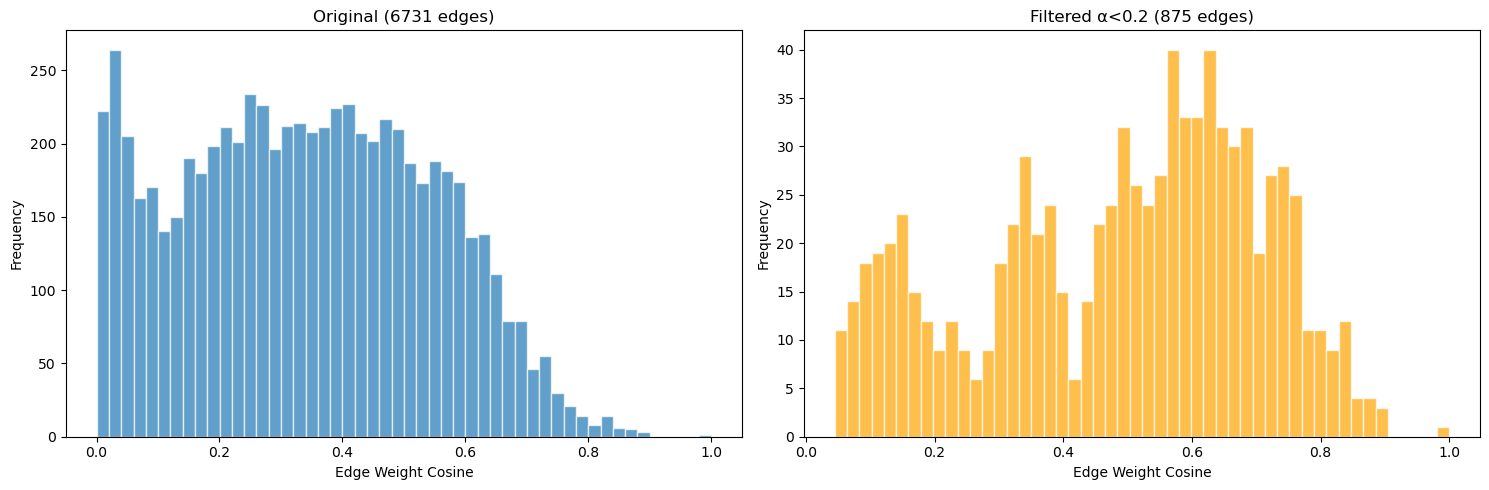

In [ ]:
# visualizations

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
weights_orig = [d['weight'] for _, _, d in G_drug_drug_se_cosine.edges(data=True)]
ax.hist(weights_orig, bins=50, edgecolor='white', alpha=0.7, label='Original')
ax.set_xlabel('Edge Weight Cosine')
ax.set_ylabel('Frequency')
ax.set_title(f'Original ({G_drug_drug_se_cosine.number_of_edges()} edges)')

ax = axes[1]
weights_filt = [d['weight'] for _, _, d in G_drug_drug_se_cosine_filter.edges(data=True)]
ax.hist(weights_filt, bins=50, edgecolor='white', alpha=0.7, color='orange', label='Filtered')
ax.set_xlabel('Edge Weight Cosine')
ax.set_ylabel('Frequency')
ax.set_title(f'Filtered α<{ALPHA_CUTOFF} ({G_drug_drug_se_cosine_filter.number_of_edges()} edges)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'disparity_filter_analysis.png', dpi=FIG_DPI, bbox_inches='tight')

In [ ]:
filtered_se_networks = {
    'Drug-Drug by SE Jaccard': G_drug_drug_se_jaccard_filter,
    'Drug-Drug by SE Cosine': G_drug_drug_se_cosine_filter}

In [ ]:
for name, G in filtered_se_networks.items():
    print(f"\n{name}:")
    # connected components
    n_components = nx.number_connected_components(G)
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"Connected components: {n_components}")
    print(f"Largest component size: {len(largest_cc)} ({100*len(largest_cc)/G.number_of_nodes():.1f}%)")

    is_bipartite = nx.is_bipartite(G)
    # clustering coef
    if is_bipartite:
        avg_clustering = nx.bipartite.average_clustering(G)
        print(f"Avg Bipartite clustering coefficient: {avg_clustering:.2f}")
    else:
        avg_clustering = nx.average_clustering(G)
        print(f"Avg clustering coefficient: {avg_clustering:.2f}")

    # av degree
    degrees = [d for n, d in G.degree()]
    print(f"Avg degree: {np.mean(degrees):.2f}")
    print(f"Median degree: {np.median(degrees)}")
    print(f"Max degree: {np.max(degrees)}")


Drug-Drug by SE Jaccard:
Connected components: 12
Largest component size: 103 (87.3%)
Avg clustering coefficient: 0.73
Avg degree: 57.00
Median degree: 72.0
Max degree: 92

Drug-Drug by SE Cosine:
Connected components: 1
Largest component size: 118 (100.0%)
Avg clustering coefficient: 0.39
Avg degree: 14.83
Median degree: 14.0
Max degree: 30


In [ ]:
G_inv = invert_weights(G_drug_drug_se_cosine_filter)

degree_cent = nx.degree_centrality(G_drug_drug_se_cosine_filter)
print("\nTop degree drugs")
for drug, cent in sorted(degree_cent.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

strength = {n:sum(d['weight'] for _, _, d in G_drug_drug_se_cosine_filter.edges(n, data=True)) for n in G_drug_drug_se_cosine_filter.nodes()}
print("\nTop by strength")
for drug, s in sorted(strength.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {s:.0f}")

closeness = nx.closeness_centrality(G_drug_drug_se_cosine_filter, distance='distance')
print("\nTop drug by closeness")
for drug, cent in sorted(closeness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

betweenness = nx.betweenness_centrality(G_drug_drug_se_cosine_filter, weight='distance')
print("\nTop drug by betweenness")
for drug, cent in sorted(betweenness.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")

pagerank = nx.pagerank(G_drug_drug_se_cosine_filter, weight='weight')
print("\nTop drug by PageRank")
for drug, cent in sorted(pagerank.items(), key=lambda x: -x[1])[:TOP_N]:
    print(f"{drug}: {cent:.4f}")


Top degree drugs
cabergoline: 0.2564
fluvoxamine: 0.2479
tapentadol: 0.2479
rotigotine: 0.2308
isocarboxazid: 0.2137

Top by strength
cabergoline: 19
tapentadol: 18
fluvoxamine: 18
rotigotine: 16
venlafaxine: 15

Top drug by closeness
tapentadol: 0.5367
fluvoxamine: 0.5200
rotigotine: 0.5109
isocarboxazid: 0.5087
nefazodone: 0.5087

Top drug by betweenness
isocarboxazid: 0.0425
rotigotine: 0.0407
fluvoxamine: 0.0369
tapentadol: 0.0359
pyridostigmine: 0.0344

Top drug by PageRank
cabergoline: 0.0193
fluvoxamine: 0.0186
tapentadol: 0.0184
rotigotine: 0.0163
trazodone: 0.0154


In [ ]:
# infomap w/o isolated components

def run_infomap(G, weighted=True):
    G_ig = ig.Graph.from_networkx(G)
    isolated_indices = [v.index for v in G_ig.vs if G_ig.degree(v.index) == 0]

    if isolated_indices:
        G_ig_clean = G_ig.copy()
        G_ig_clean.delete_vertices(isolated_indices)

        weights = G_ig_clean.es['weight'] if weighted and G_ig_clean.ecount() > 0 else None
        result = G_ig_clean.community_infomap(edge_weights=weights)
        membership_clean = result.membership
        codelength = result.codelength
        max_comm = max(membership_clean) + 1
        membership = [0] * G_ig.vcount()

        clean_idx = 0
        for i in range(G_ig.vcount()):
            if i in isolated_indices:
                membership[i] = max_comm
                max_comm += 1
            else:
                membership[i] = membership_clean[clean_idx]
                clean_idx += 1
    else:
        weights = G_ig.es['weight'] if weighted else None
        result = G_ig.community_infomap(edge_weights=weights)
        membership = result.membership
        codelength = result.codelength

    n_communities = len(set(membership))
    weights_mod = G_ig.es['weight'] if weighted else None
    modularity = G_ig.modularity(membership, weights=weights_mod)
    partition = {G_ig.vs[i]['_nx_name']: membership[i] for i in range(len(G_ig.vs))}

    return partition, membership, n_communities, modularity, G_ig, codelength

In [ ]:
# run algorithms

results = {}

for name, G in filtered_se_networks.items():
    print(f"{name}")
    results[name] = {}

    # Louvain with ModularityVertexPartition
    print("\nLouvain with ModularityVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, partition_type='modularity')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_mod'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Louvain with RBConfiguration
    print("\nLouvain RBConfigurationVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, resolution=1.0, partition_type='rb')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_rb'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Louvain CPM
    print("\nLouvain CPMVertexPartition")
    partition, membership, quality, n_comm, modularity, G_ig = run_louvain(
        G, weighted=True, resolution=0.1, partition_type='cpm')

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Quality: {quality:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['louvain_cpm'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'quality': quality,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

    # Infomap
    print("\nInfomap")
    partition, membership, n_comm, modularity, G_ig, codelength = run_infomap(
        G, weighted=True)

    ncut = compute_ncut(G_ig, membership, weighted=True)
    nmi_int = compute_nmi_internal(G_ig, membership, weighted=True)

    print(f"Communities: {n_comm}")
    print(f"Codelength: {codelength:.4f}")
    print(f"Modularity: {modularity:.4f}")
    print(f"NCut: {ncut:.4f}")
    print(f"NMI: {nmi_int:.4f}")
    sizes = [membership.count(c) for c in set(membership)]
    print(f"Sizes: {sorted(sizes, reverse=True)}")

    results[name]['infomap'] = {
        'partition': partition,
        'membership': membership,
        'n_communities': n_comm,
        'codelength': codelength,
        'modularity': modularity,
        'ncut': ncut,
        'nmi': nmi_int}

Drug-Drug by SE Jaccard

Louvain with ModularityVertexPartition
Communities: 14
Quality: 0.1236
Modularity: 0.1236
NCut: 0.3285
NMI: 1.0000
Sizes: [44, 38, 21, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Louvain RBConfigurationVertexPartition
Communities: 14
Quality: 152.2744
Modularity: 0.1236
NCut: 0.3285
NMI: 1.0000
Sizes: [44, 38, 21, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Louvain CPMVertexPartition
Communities: 23
Quality: 463.3361
Modularity: 0.0387
NCut: 0.7864
NMI: 1.0000
Sizes: [75, 10, 5, 3, 3, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Infomap
Communities: 12
Codelength: 6.5044
Modularity: 0.0020
NCut: 0.0000
NMI: 1.0000
Sizes: [103, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Drug-Drug by SE Cosine

Louvain with ModularityVertexPartition
Communities: 5
Quality: 0.4642
Modularity: 0.4642
NCut: 0.3427
NMI: 1.0000
Sizes: [30, 30, 25, 24, 9]

Louvain RBConfigurationVertexPartition
Communities: 5
Quality: 396.4011
Modularity: 0.4642
NCut: 0.3427
NMI: 1.0000
Sizes: [30, 30, 25, 24, 9]

Louvain

In [ ]:
algorithms = ['louvain_mod', 'louvain_rb', 'louvain_cpm', 'infomap']
alg_names = ['Louvain (Mod)', 'Louvain (RB)', 'Louvain (CPM)', 'Infomap']

for name in results.keys():
    print(name)
    for alg, alg_name in zip(algorithms, alg_names):
        r = results[name][alg]
        n_comm = r.get('n_communities')
        modularity = r.get('modularity')
        ncut = r.get('ncut')
        nmi = r.get('nmi')
        print(f"{alg_name}: {n_comm} communities, modularity={modularity:.4f}, Ncut={ncut:.4f}, NMI={nmi:.4f}")

Drug-Drug by SE Jaccard
Louvain (Mod): 14 communities, modularity=0.1236, Ncut=0.3285, NMI=1.0000
Louvain (RB): 14 communities, modularity=0.1236, Ncut=0.3285, NMI=1.0000
Louvain (CPM): 23 communities, modularity=0.0387, Ncut=0.7864, NMI=1.0000
Infomap: 12 communities, modularity=0.0020, Ncut=0.0000, NMI=1.0000
Drug-Drug by SE Cosine
Louvain (Mod): 5 communities, modularity=0.4642, Ncut=0.3427, NMI=1.0000
Louvain (RB): 5 communities, modularity=0.4642, Ncut=0.3427, NMI=1.0000
Louvain (CPM): 19 communities, modularity=0.4275, Ncut=0.7505, NMI=1.0000
Infomap: 7 communities, modularity=0.4591, Ncut=0.4199, NMI=1.0000


In [ ]:
alg_attr_names = {
    'louvain_mod': 'comm_louvain_mod',
    'louvain_rb': 'comm_louvain_rb',
    'louvain_cpm': 'comm_louvain_cpm',
    'infomap': 'comm_infomap'}

In [ ]:
G = G_drug_drug_se_jaccard_filter.copy()
network_name = 'Drug-Drug by SE Jaccard'
G_inv = invert_weights(G)
degree_cent = nx.degree_centrality(G)
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
closeness = nx.closeness_centrality(G_inv, distance='distance')
betweenness = nx.betweenness_centrality(G_inv, weight='distance')
pagerank = nx.pagerank(G, weight='weight')

for alg in algorithms:
    partition = results[network_name][alg]['partition']
    attr_name = alg_attr_names[alg]
    nx.set_node_attributes(G, partition, attr_name)

for node in G.nodes():
    if node in atc_map:
        G.nodes[node]['atc_full'] = atc_map[node]['atc_full']
        G.nodes[node]['atc2'] = atc_map[node]['atc2']
        G.nodes[node]['atc3'] = atc_map[node]['atc3']
        G.nodes[node]['atc4'] = atc_map[node]['atc4']

nx.set_node_attributes(G, degree_cent, 'degree_centrality')
nx.set_node_attributes(G, strength, 'strength')
nx.set_node_attributes(G, closeness, 'closeness_centrality')
nx.set_node_attributes(G, betweenness, 'betweenness_centrality')
nx.set_node_attributes(G, pagerank, 'pagerank')

In [ ]:
with open(OUT_DIR / 'drug_drug_se_jaccard_communities.pkl', 'wb') as f:
    pickle.dump(G, f)
nx.write_graphml(G, NET_DIR / 'drug_drug_se_jaccard_communities.graphml')
results_to_save = {alg: results[network_name][alg] for alg in algorithms}
with open(OUT_DIR / 'community_detection_results_jaccard.pkl', 'wb') as f:
    pickle.dump(results_to_save, f)

In [ ]:
G = G_drug_drug_se_cosine_filter.copy()
network_name = 'Drug-Drug by SE Cosine'
G_inv = invert_weights(G)
degree_cent = nx.degree_centrality(G)
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
closeness = nx.closeness_centrality(G_inv, distance='distance')
betweenness = nx.betweenness_centrality(G_inv, weight='distance')
pagerank = nx.pagerank(G, weight='weight')

for alg in algorithms:
    partition = results[network_name][alg]['partition']
    attr_name = alg_attr_names[alg]
    nx.set_node_attributes(G, partition, attr_name)

for node in G.nodes():
    if node in atc_map:
        G.nodes[node]['atc_full'] = atc_map[node]['atc_full']
        G.nodes[node]['atc2'] = atc_map[node]['atc2']
        G.nodes[node]['atc3'] = atc_map[node]['atc3']
        G.nodes[node]['atc4'] = atc_map[node]['atc4']

nx.set_node_attributes(G, degree_cent, 'degree_centrality')
nx.set_node_attributes(G, strength, 'strength')
nx.set_node_attributes(G, closeness, 'closeness_centrality')
nx.set_node_attributes(G, betweenness, 'betweenness_centrality')
nx.set_node_attributes(G, pagerank, 'pagerank')

In [ ]:
with open(OUT_DIR / 'drug_drug_se_cosine_communities.pkl', 'wb') as f:
    pickle.dump(G, f)
nx.write_graphml(G, NET_DIR / 'drug_drug_se_cosine_communities.graphml')
results_to_save = {alg: results[network_name][alg] for alg in algorithms}
with open(OUT_DIR / 'community_detection_results_cosine.pkl', 'wb') as f:
    pickle.dump(results_to_save, f)

## ATC composition and assortativity

In [ ]:
networks_analysis = {
    'Drug-Drug by Indication': G_drug_drug_ind,
    'Drug-Drug by SE Cosine': G_drug_drug_se_cosine_filter}

for G in networks_analysis.values():
    for node in G.nodes():
        if node in atc_map:
            G.nodes[node]['atc_full'] = atc_map[node]['atc_full']
            G.nodes[node]['atc2'] = atc_map[node]['atc2']
            G.nodes[node]['atc3'] = atc_map[node]['atc3']
            G.nodes[node]['atc4'] = atc_map[node]['atc4']

atc_levels = ['atc2', 'atc3', 'atc4', 'atc_full']

In [ ]:
def get_community_composition(G, partition, atc_level='atc2'):
    communities = {}
    for node, comm_id in partition.items():
        if comm_id not in communities:
            communities[comm_id] = []
        communities[comm_id].append(G.nodes[node].get(atc_level, 'unknown'))

    composition = {comm_id: Counter(atc_list) for comm_id, atc_list in communities.items()}
    df = pd.DataFrame(composition).fillna(0).astype(int).T.sort_index()
    df.index.name = 'community'
    return df


def plot_community_composition(composition_df, network_name, atc_level):
    composition_pct = composition_df.div(composition_df.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    composition_df.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
    axes[0].set_xlabel('Community')
    axes[0].set_ylabel('Number of Drugs')
    axes[0].set_title(f'{network_name}: {atc_level.upper()} (counts)')
    axes[0].legend(title=atc_level.upper(), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    axes[0].tick_params(axis='x', rotation=0)

    composition_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
    axes[1].set_xlabel('Community')
    axes[1].set_ylabel('Percentage')
    axes[1].set_title(f'{network_name}: {atc_level.upper()} (%)')
    axes[1].legend(title=atc_level.upper(), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    return fig

In [ ]:
G_ig_ind = ig.Graph.from_networkx(G_drug_drug_ind)
weights_ind = G_ig_ind.es['weight'] if G_ig_ind.ecount() > 0 else None
partition_ind_result = la.find_partition(G_ig_ind, la.ModularityVertexPartition, weights=weights_ind)
partition_ind = {G_ig_ind.vs[i]['_nx_name']: partition_ind_result.membership[i] for i in range(len(G_ig_ind.vs))}

partitions_to_analyze = {
    'Drug-Drug by Indication': partition_ind,
    'Drug-Drug by SE Cosine': results['Drug-Drug by SE Cosine']['louvain_mod']['partition']}

Drug-Drug by Indication 14 communities
ATC2 dominant per community:
Comm 0: N06 (85.7%)
Comm 1: N02 (54.5%)
Comm 2: N03 (75.0%)
Comm 3: N04 (91.7%)
Comm 4: N05 (63.6%)
Comm 5: N05 (100.0%)
Comm 6: N02 (100.0%)
Comm 7: N06 (100.0%)
Comm 8: N07 (100.0%)
Comm 9: N01 (100.0%)
Comm 10: N07 (100.0%)
Comm 11: N03 (100.0%)
Comm 12: N07 (100.0%)
Comm 13: N07 (100.0%)


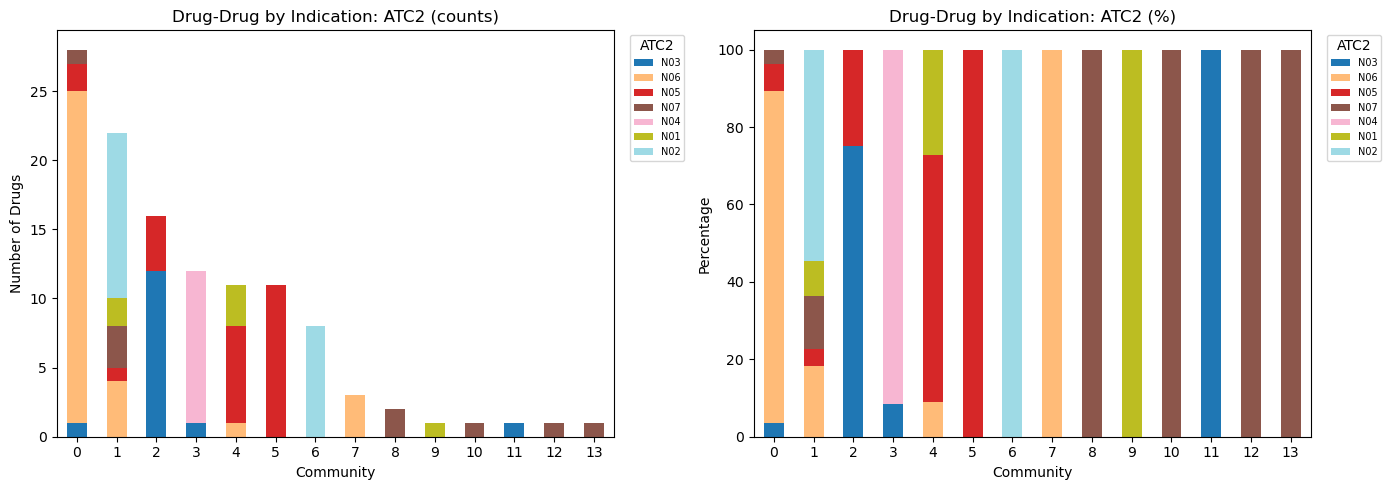

ATC3 dominant per community:
Comm 0: N06A (85.7%)
Comm 1: N02A (40.9%)
Comm 2: N03A (75.0%)
Comm 3: N04B (91.7%)
Comm 4: N05C (63.6%)
Comm 5: N05A (100.0%)
Comm 6: N02C (100.0%)
Comm 7: N06D (100.0%)
Comm 8: N07A (100.0%)
Comm 9: N01A (100.0%)
Comm 10: N07C (100.0%)
Comm 11: N03A (100.0%)
Comm 12: N07X (100.0%)
Comm 13: N07X (100.0%)


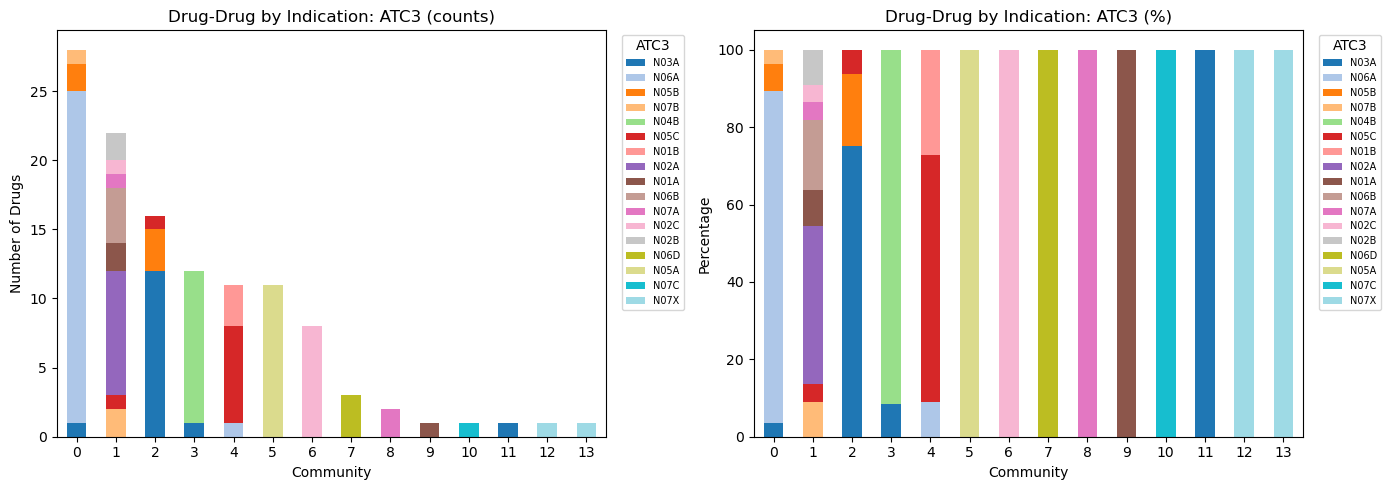

Drug-Drug by SE Cosine 5 communities
ATC2 dominant per community:
Comm 0: N03 (43.3%)
Comm 1: N04 (36.7%)
Comm 2: N05 (64.0%)
Comm 3: N06 (70.8%)
Comm 4: N05 (44.4%)


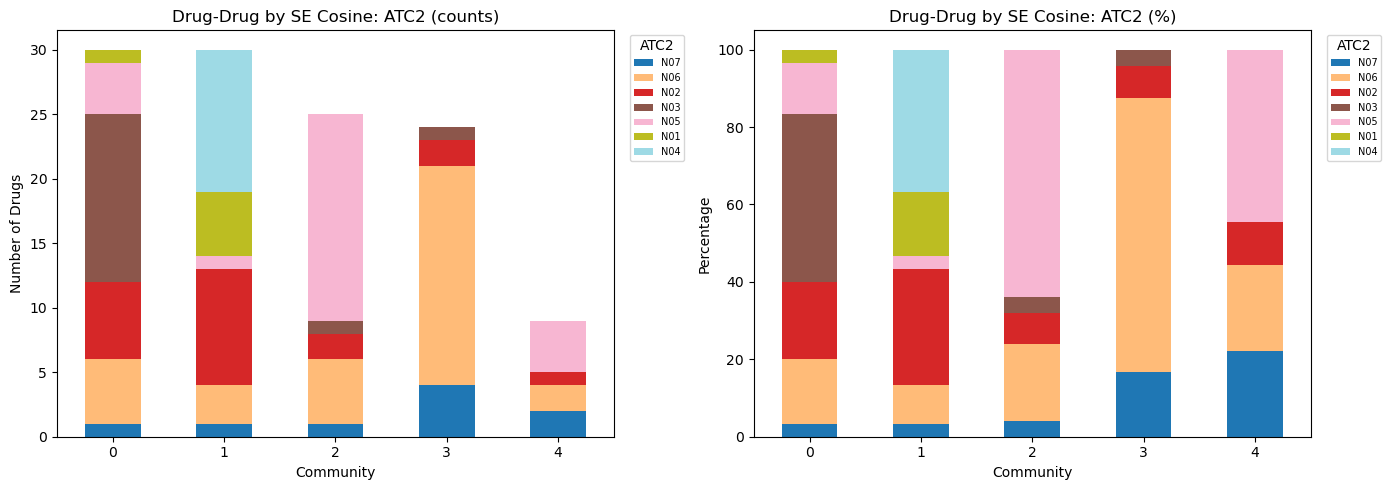

ATC3 dominant per community:
Comm 0: N03A (43.3%)
Comm 1: N04B (36.7%)
Comm 2: N05A (40.0%)
Comm 3: N06A (58.3%)
Comm 4: N05C (44.4%)


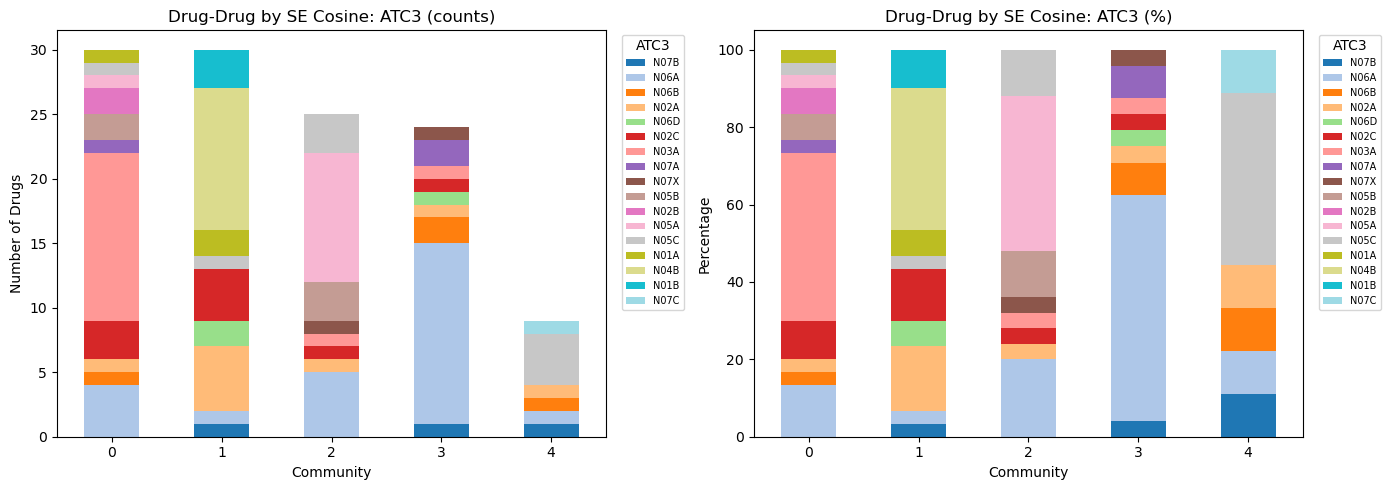

In [ ]:
for net_name, G in networks_analysis.items():
    partition = partitions_to_analyze[net_name]
    n_communities = len(set(partition.values()))
    print(f"{net_name} {n_communities} communities")

    for atc_level in ['atc2', 'atc3']:
        comp_df = get_community_composition(G, partition, atc_level)

        dominant = comp_df.idxmax(axis=1)
        dominant_pct = comp_df.max(axis=1) / comp_df.sum(axis=1) * 100

        print(f"{atc_level.upper()} dominant per community:")
        for comm_id in sorted(comp_df.index):
            print(f"Comm {comm_id}: {dominant[comm_id]} ({dominant_pct[comm_id]:.1f}%)")

        fig = plot_community_composition(comp_df, net_name, atc_level)
        filename = f"community_composition_{net_name.replace(' ', '_').replace('-', '').lower()}_{atc_level}.png"
        plt.savefig(FIG_DIR / filename, dpi=FIG_DPI, bbox_inches="tight")
        plt.show()

In [ ]:
# assortativity by atc groups

def compute_mixing_matrix(G, atc_level='atc2', weighted=True):
    atc_values = sorted(set(G.nodes[n].get(atc_level, 'unknown') for n in G.nodes()))
    atc_to_idx = {v: i for i, v in enumerate(atc_values)}
    n_classes = len(atc_values)
    mixing = np.zeros((n_classes, n_classes))

    for u, v, d in G.edges(data=True):
        atc_u = G.nodes[u].get(atc_level, 'unknown')
        atc_v = G.nodes[v].get(atc_level, 'unknown')
        i, j = atc_to_idx[atc_u], atc_to_idx[atc_v]
        w = d.get('weight', 1) if weighted else 1
        mixing[i, j] += w
        if i != j:
            mixing[j, i] += w

    return pd.DataFrame(mixing, index=atc_values, columns=atc_values)


def plot_mixing_matrix(mixing_df, network_name, atc_level):
    row_sums = mixing_df.sum(axis=1)
    normalized = mixing_df.div(row_sums, axis=0).fillna(0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(np.log1p(mixing_df.values), cmap='Blues', aspect='auto')
    axes[0].set_xticks(range(len(mixing_df.columns)))
    axes[0].set_yticks(range(len(mixing_df.index)))
    axes[0].set_xticklabels(mixing_df.columns, rotation=90, fontsize=8)
    axes[0].set_yticklabels(mixing_df.index, fontsize=8)
    axes[0].set_title(f'{network_name}: {atc_level.upper()} mixing (log)')
    plt.colorbar(im0, ax=axes[0], label='log(weight + 1)')

    im1 = axes[1].imshow(normalized.values, cmap='Reds', aspect='auto', vmin=0, vmax=1)
    axes[1].set_xticks(range(len(normalized.columns)))
    axes[1].set_yticks(range(len(normalized.index)))
    axes[1].set_xticklabels(normalized.columns, rotation=90, fontsize=8)
    axes[1].set_yticklabels(normalized.index, fontsize=8)
    axes[1].set_title(f'{network_name}: {atc_level.upper()} mixing (normalized)')
    plt.colorbar(im1, ax=axes[1], label='Proportion')
    plt.tight_layout()
    return fig

Drug-Drug by Indication
ATC Attribute Assortativity:
ATC2: r = +0.6419 (assortative, 7 classes)
ATC3: r = +0.6214 (assortative, 17 classes)
ATC4: r = +0.2235 (assortative, 46 classes)
ATC_FULL: r = -0.0126 (neutral, 118 classes)
Within-class connection ratio:
ATC2: 58.72%


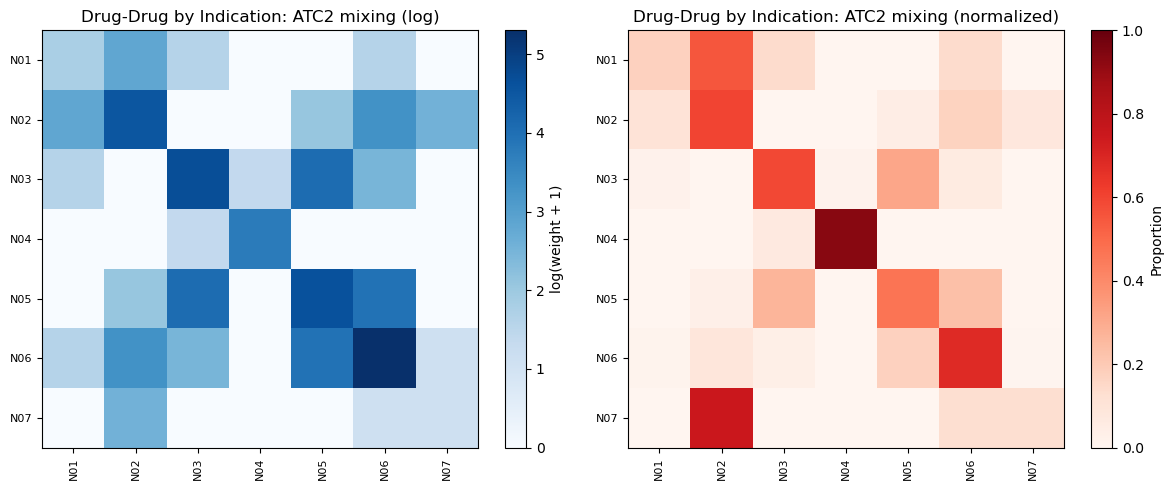

ATC3: 54.13%


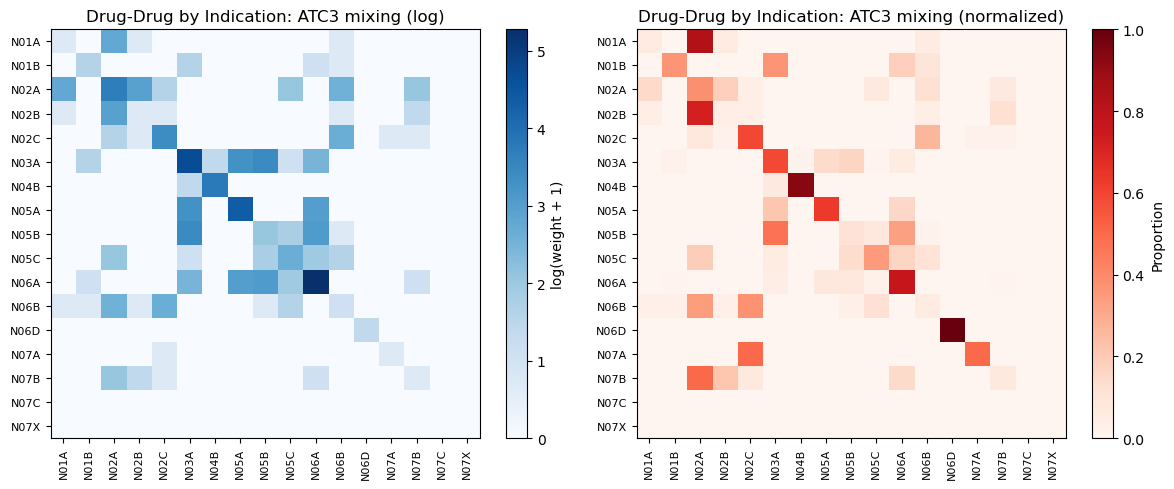

Drug-Drug by SE Cosine
ATC Attribute Assortativity:
ATC2: r = +0.2231 (assortative, 7 classes)
ATC3: r = +0.1900 (assortative, 17 classes)
ATC4: r = +0.0786 (neutral, 46 classes)
ATC_FULL: r = -0.0097 (neutral, 118 classes)
Within-class connection ratio:
ATC2: 27.97%


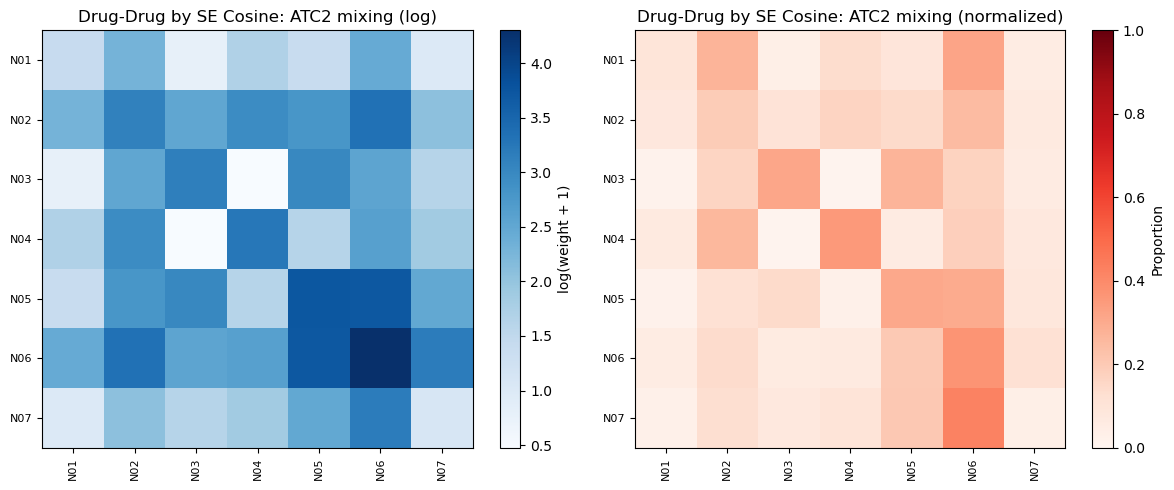

ATC3: 20.44%


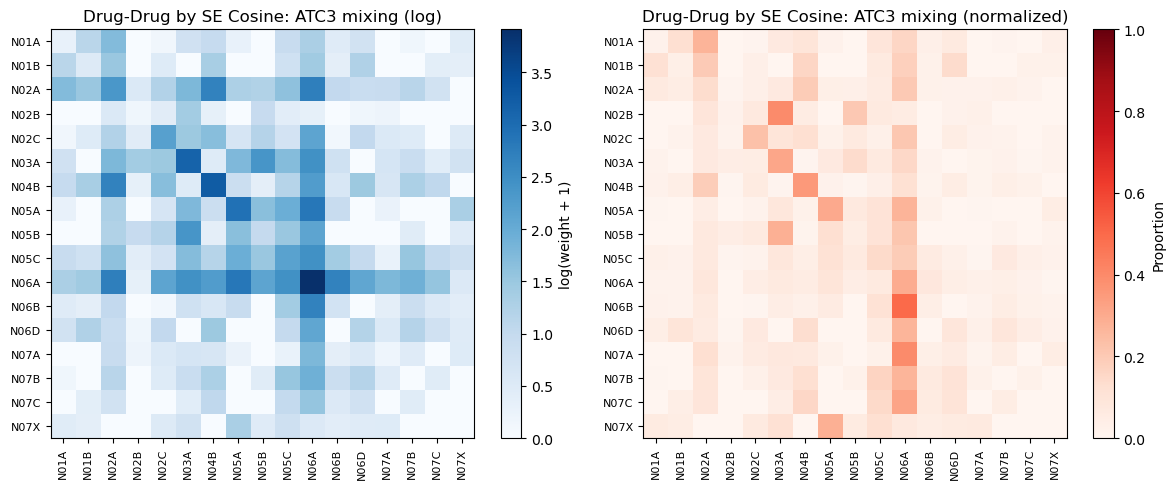

In [ ]:
for net_name, G in networks_analysis.items():
    print(f"{net_name}")
    print(f"ATC Attribute Assortativity:")
    for atc_level in atc_levels:
        try:
            r_atc = nx.attribute_assortativity_coefficient(G, atc_level)
            n_classes = len(set(G.nodes[n].get(atc_level, 'unknown') for n in G.nodes()))
            interp = "assortative" if r_atc > 0.1 else "disassortative" if r_atc < -0.1 else "neutral"
            print(f"{atc_level.upper()}: r = {r_atc:+.4f} ({interp}, {n_classes} classes)")
        except:
            print(f"{atc_level.upper()}: could not compute")

    print(f"Within-class connection ratio:")
    for atc_level in ['atc2', 'atc3']:
        mixing_df = compute_mixing_matrix(G, atc_level, weighted=True)
        diag_sum = np.trace(mixing_df.values)
        total_sum = mixing_df.values.sum()
        within_ratio = diag_sum / total_sum if total_sum > 0 else 0
        print(f"{atc_level.upper()}: {within_ratio:.2%}")
        fig = plot_mixing_matrix(mixing_df, net_name, atc_level)
        filename = f"mixing_matrix_{net_name.replace(' ', '_').replace('-', '').lower()}_{atc_level}.png"
        plt.savefig(FIG_DIR / filename, dpi=FIG_DPI, bbox_inches="tight")
        plt.show()

In [ ]:
assortativity_data = []
for net_name, G in networks_analysis.items():
    row = {'network': net_name}
    row['degree'] = nx.degree_assortativity_coefficient(G, weight='weight')
    for atc_level in atc_levels:
        try:
            row[atc_level] = nx.attribute_assortativity_coefficient(G, atc_level)
        except:
            row[atc_level] = np.nan
    assortativity_data.append(row)

assortativity_df = pd.DataFrame(assortativity_data).set_index('network')
assortativity_df.to_csv(OUT_DIR / "assortativity_results.csv")

In [ ]:
# repositioning example
anchor = 'risperidone'

se_burden = {n: sum(G_drug_se_weighted[n][nb]['weight']
             for nb in G_drug_se_weighted.neighbors(n))
             for n in drug_nodes}

ind_neighbors = {nb: G_drug_drug_ind[anchor][nb]['weight']
                 for nb in G_drug_drug_ind.neighbors(anchor)}

cosine_to_anchor = {nb: G_drug_drug_se_cosine[anchor][nb]['weight']
                    if G_drug_drug_se_cosine.has_edge(anchor, nb) else 0
                    for nb in ind_neighbors}

anchor_burden = se_burden[anchor]
max_overlap = max(ind_neighbors.values())

candidates = []
for drug, ind_sim in ind_neighbors.items():
    burden     = se_burden.get(drug, 0)
    cosine_sim = cosine_to_anchor.get(drug, 0)
    if burden < anchor_burden and ind_sim >= MIN_OVERLAP:
        score = (ind_sim / max_overlap) ** 2 \
              * (1 - burden / anchor_burden)  \
              * (1 - cosine_sim)
        candidates.append({
            'drug' : drug,
            'indication_overlap': int(ind_sim),
            'se_burden' : round(burden, 2),
            'cosine_se_similarity': round(cosine_sim, 3),
            'score' : round(score, 4)})

df_candidates = pd.DataFrame(candidates).sort_values('score', ascending=False)
print(df_candidates.head(10))

            drug  indication_overlap  se_burden  cosine_se_similarity   score
5   aripiprazole                   5       4.97                 0.580  0.3120
3    ziprasidone                   4       4.02                 0.474  0.2668
1  carbamazepine                   3       4.49                 0.354  0.1787
0      asenapine                   3       2.05                 0.469  0.1711
4     olanzapine                   4      10.04                 0.465  0.1653
2     quetiapine                   3       7.79                 0.570  0.0926


In [ ]:
# centrality scatter plots

def build_centrality_df(G, atc_map):
    G_inv = invert_weights(G)
    degree = nx.degree_centrality(G)
    between = nx.betweenness_centrality(G_inv, weight='distance')
    pagerank = nx.pagerank(G, weight='weight')
    records = []
    for node in G.nodes():
        records.append({
            'drug': node,
            'degree': degree[node],
            'between': between[node],
            'pagerank': pagerank[node],
            'atc2': atc_map.get(node, {}).get('atc2', 'N/A')})
    return pd.DataFrame(records).set_index('drug')

df_ind = build_centrality_df(G_drug_drug_ind, atc_map)
df_cosine = build_centrality_df(G_drug_drug_se_cosine_filter, atc_map)

atc2_classes = sorted(set(df_ind['atc2']) | set(df_cosine['atc2']))
palette = plt.get_cmap('tab10')
colour_map = {atc: palette(i % 10) for i, atc in enumerate(atc2_classes)}

def get_colours(df):
    return [colour_map.get(a, 'grey') for a in df['atc2']]

def get_labels(df, col_x, col_y, n=5):
    return set(df[col_x].nlargest(n).index) | set(df[col_y].nlargest(n).index)

def scatter_panel(ax, df, col_x, col_y, xlabel, ylabel, title):
    colours = get_colours(df)
    ax.scatter(df[col_x], df[col_y], c=colours,
               s=38, alpha=0.82, edgecolors='white', linewidths=0.5, zorder=3)
    ax.axvline(df[col_x].median(), color='#bbb', lw=0.8, ls='--', zorder=1)
    ax.axhline(df[col_y].median(), color='#bbb', lw=0.8, ls='--', zorder=1)

    labels = get_labels(df, col_x, col_y, n=4)
    texts  = [ax.text(df.loc[d, col_x], df.loc[d, col_y], d, fontsize=7.5, color='#333')
        for d in labels if d in df.index]
    adjust_text(
        texts,
        x=df[col_x].values, y=df[col_y].values,
        ax=ax,
        expand=(1.8, 2.0),
        arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.6))

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight='bold', loc='left')
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(lw=0.3, color='#eee', zorder=0)

pairs = [('degree', 'between', 'Degree centrality', 'Betweenness centrality'),
         ('pagerank', 'between', 'PageRank', 'Betweenness centrality'),
         ('degree', 'pagerank', 'Degree centrality', 'PageRank')]

In [ ]:
df_to_plot = df_ind
net_name = 'Drug–Drug Indication'

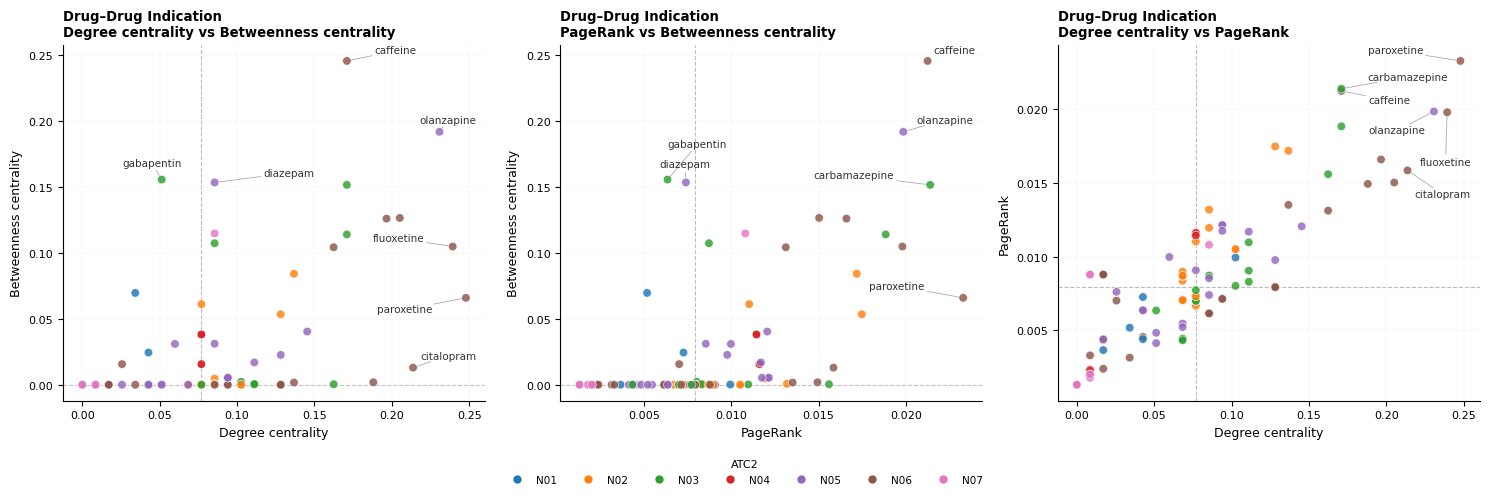

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.32, bottom=0.28)

for col_idx, (cx, cy, xl, yl) in enumerate(pairs):
    scatter_panel(axes[col_idx], df_to_plot, cx, cy, xl, yl,
                  title=f'{net_name}\n{xl} vs {yl}')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=colour_map[atc], markersize=7, label=atc)
           for atc in atc2_classes]
fig.legend(handles=handles, title='ATC2', title_fontsize=8,
           fontsize=7.5, loc='lower center', ncol=len(atc2_classes),
           frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(FIG_DIR / 'ind_cent.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

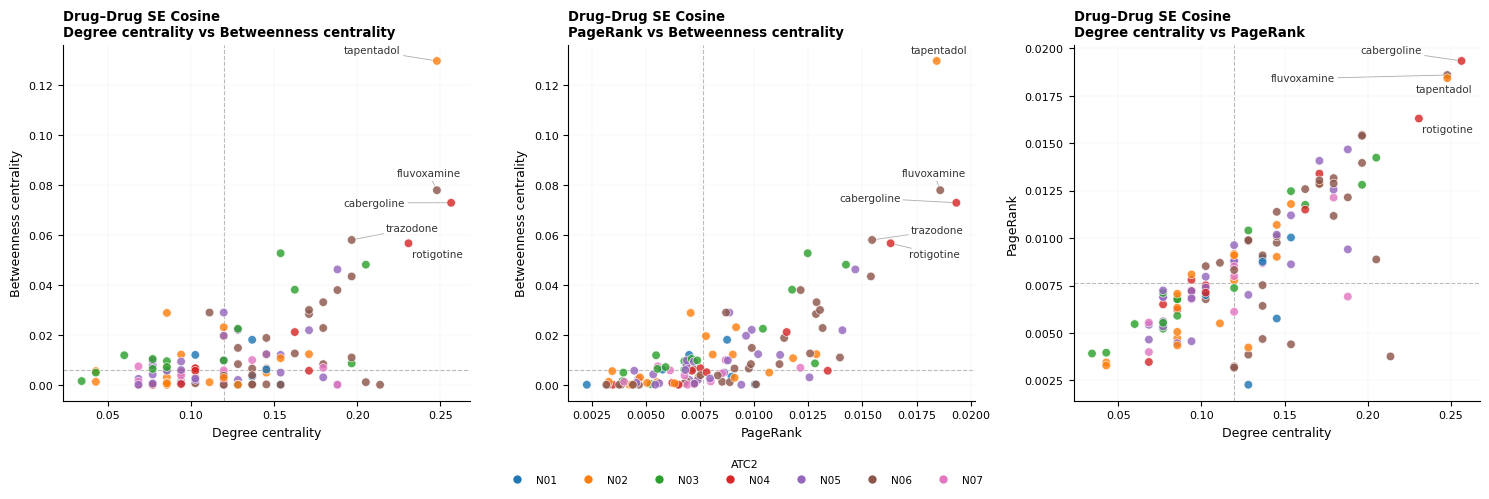

In [ ]:
df_to_plot = df_cosine
net_name = 'Drug–Drug SE Cosine'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.32, bottom=0.28)

for col_idx, (cx, cy, xl, yl) in enumerate(pairs):
    scatter_panel(axes[col_idx], df_to_plot, cx, cy, xl, yl,
                  title=f'{net_name}\n{xl} vs {yl}')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=colour_map[atc], markersize=7, label=atc)
           for atc in atc2_classes]
fig.legend(handles=handles, title='ATC2', title_fontsize=8,
           fontsize=7.5, loc='lower center', ncol=len(atc2_classes),
           frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(FIG_DIR / 'cos_cent.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()